In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import networkx as nx

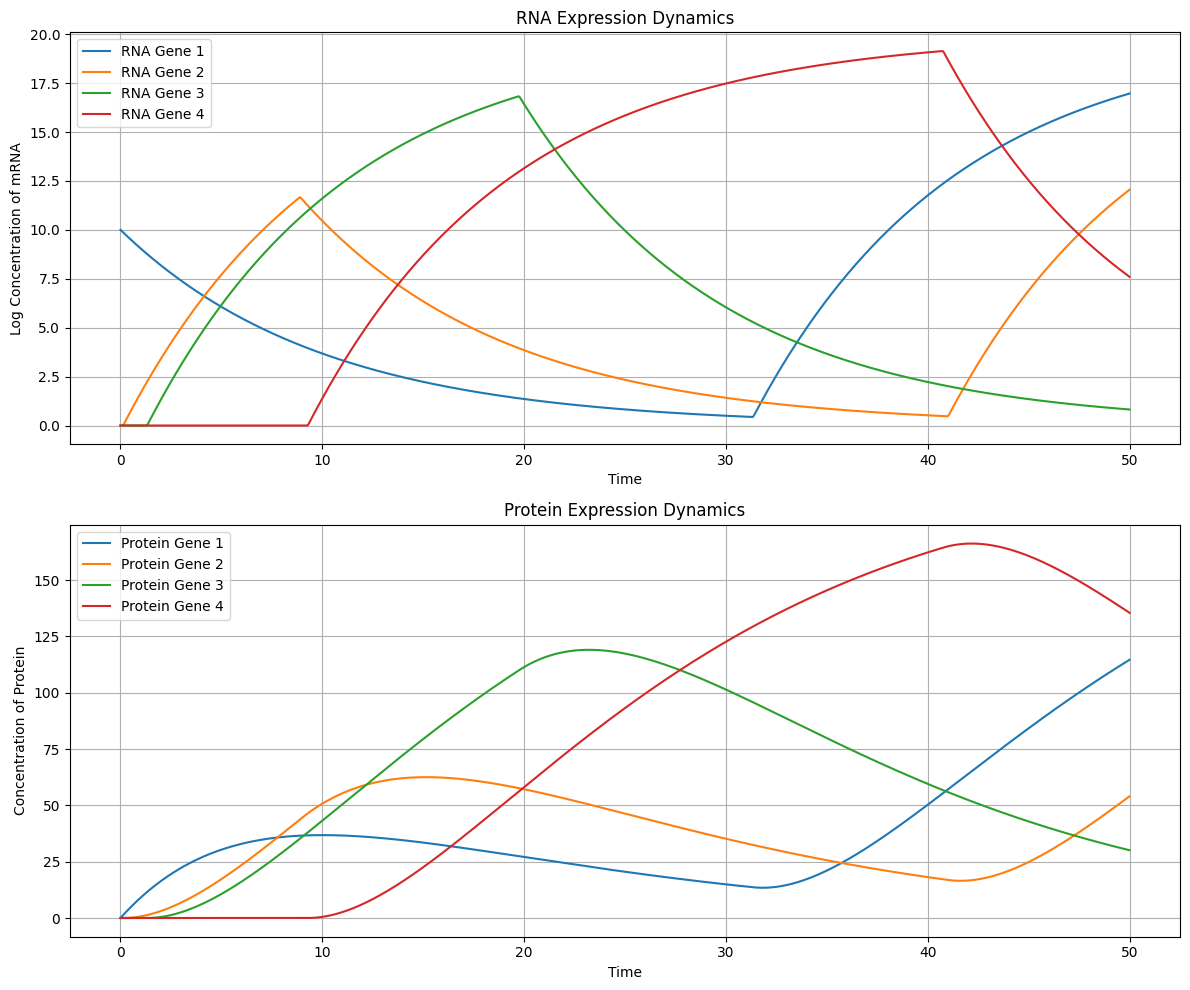

{'time': array([ 0.        ,  0.05005005,  0.1001001 ,  0.15015015,  0.2002002 ,
         0.25025025,  0.3003003 ,  0.35035035,  0.4004004 ,  0.45045045,
         0.5005005 ,  0.55055055,  0.6006006 ,  0.65065065,  0.7007007 ,
         0.75075075,  0.8008008 ,  0.85085085,  0.9009009 ,  0.95095095,
         1.001001  ,  1.05105105,  1.1011011 ,  1.15115115,  1.2012012 ,
         1.25125125,  1.3013013 ,  1.35135135,  1.4014014 ,  1.45145145,
         1.5015015 ,  1.55155155,  1.6016016 ,  1.65165165,  1.7017017 ,
         1.75175175,  1.8018018 ,  1.85185185,  1.9019019 ,  1.95195195,
         2.002002  ,  2.05205205,  2.1021021 ,  2.15215215,  2.2022022 ,
         2.25225225,  2.3023023 ,  2.35235235,  2.4024024 ,  2.45245245,
         2.5025025 ,  2.55255255,  2.6026026 ,  2.65265265,  2.7027027 ,
         2.75275275,  2.8028028 ,  2.85285285,  2.9029029 ,  2.95295295,
         3.003003  ,  3.05305305,  3.1031031 ,  3.15315315,  3.2032032 ,
         3.25325325,  3.3033033 ,  3.353353

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def simulate_and_plot_gene_expression(u0, beta, s, interactions, t_end=50, num_points=1000, thresh=1.3, L=1, U=0.1):
    """
    Simulates gene expression dynamics, including protein concentration, with interaction-based regulation.

    Parameters:
    - u0 (list or array): Initial concentrations of unspliced RNA for each gene.
    - beta (list or array): Maximum transcription rates when genes are "on".
    - s (list or array): Splicing rates for each gene.
    - interactions (numpy array): Interaction matrix defining the influence between genes.
    - t_end (float): End time for the simulation.
    - num_points (int): Number of time points for the simulation.
    - thresh (float): Threshold for gene activation based on interaction influence.
    - L (float): Translation rate constant.
    - U (float): Protein degradation rate constant.
    """

    # Ensure threshold is array-like for flexibility
    thresh = np.array(thresh if hasattr(thresh, "__len__") else [thresh] * len(u0))
    
    # Define the regulatory function based on gene interactions
    def interaction_regulatory_function(interactions, u):
        influence = np.dot(interactions.T, u)
        return (influence > thresh).astype(int)

    # Define the ODE model incorporating protein dynamics
    def grn_model(y, t, beta, s, interactions, L, U):
        u = y[:len(u0)]   # RNA concentrations
        p = y[len(u0):]   # Protein concentrations

        du_dt = np.zeros_like(u)
        dp_dt = np.zeros_like(p)

        # Compute the regulatory states based on interactions and current RNA levels
        active = interaction_regulatory_function(interactions, p)
        
        for i in range(len(u)):
            # RNA dynamics: transcription - splicing
            du_dt[i] = beta[i] * active[i] - s[i] * u[i]
            # Protein dynamics: translation - degradation
            dp_dt[i] = L * u[i] - U * p[i]
        
        return np.concatenate([du_dt, dp_dt])

    # Initial conditions for both RNA and protein
    y0 = np.concatenate([u0, np.zeros_like(u0)])

    # Time points for simulation
    t = np.linspace(0, t_end, num_points)
    
    # Solve the system of ODEs
    solution = odeint(grn_model, y0, t, args=(beta, s, interactions, L, U))
    
    # Separate RNA and protein from the solution
    rna_solution = solution[:, :len(u0)]
    protein_solution = solution[:, len(u0):]
    
    # Plotting RNA and Protein concentrations
    plt.figure(figsize=(12, 10))
    
    # Plot RNA dynamics
    plt.subplot(2, 1, 1)
    labels = [f'RNA Gene {i+1}' for i in range(len(u0))]
    for i in range(len(u0)):
        plt.plot(t, rna_solution[:, i], label=labels[i])
    plt.xlabel('Time')
    plt.ylabel('Log Concentration of mRNA')
    plt.title('RNA Expression Dynamics')
    plt.legend()
    plt.grid(True)

    # Plot Protein dynamics
    plt.subplot(2, 1, 2)
    labels = [f'Protein Gene {i+1}' for i in range(len(u0))]
    for i in range(len(u0)):
        plt.plot(t, protein_solution[:, i], label=labels[i])
    plt.xlabel('Time')
    plt.ylabel('Concentration of Protein')
    plt.title('Protein Expression Dynamics')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Returning detailed results for analysis
    results = {'time': t, 'rna_levels': rna_solution, 'protein_levels': protein_solution}
    return results

# Example usage
u0 = [10, 0, 0, 0]  # Initial concentrations of unspliced RNA for each gene
beta = [2, 2, 2, 2]  # Maximum transcription rates when genes are "on"
s = [0.1] * 4  # Splicing rates for each gene
interactions = np.array([
    [0, 1, 0, -1],    # Gene1 activates Gene2 and represses Gene4
    [-1, 0, 1, 0],    # Gene2 inhibits Gene1 and activates Gene3
    [-1, -1, 0, 1],   # Gene3 represses Gene1, Gene2 and activates Gene4
    [1, 0, -1, 0]     # Gene4 activates Gene1 and represses Gene3
])

simulate_and_plot_gene_expression(u0, beta, s, interactions)

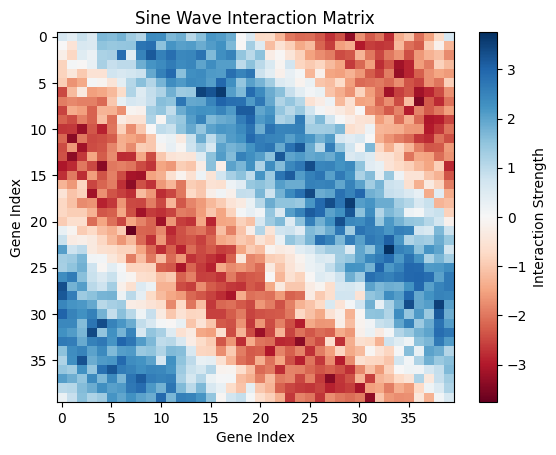

/var/folders/q4/2fqjcfrs3k36ykkvbcqd0bcc0000gp/T/ipykernel_61326/2958610667.py:86: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


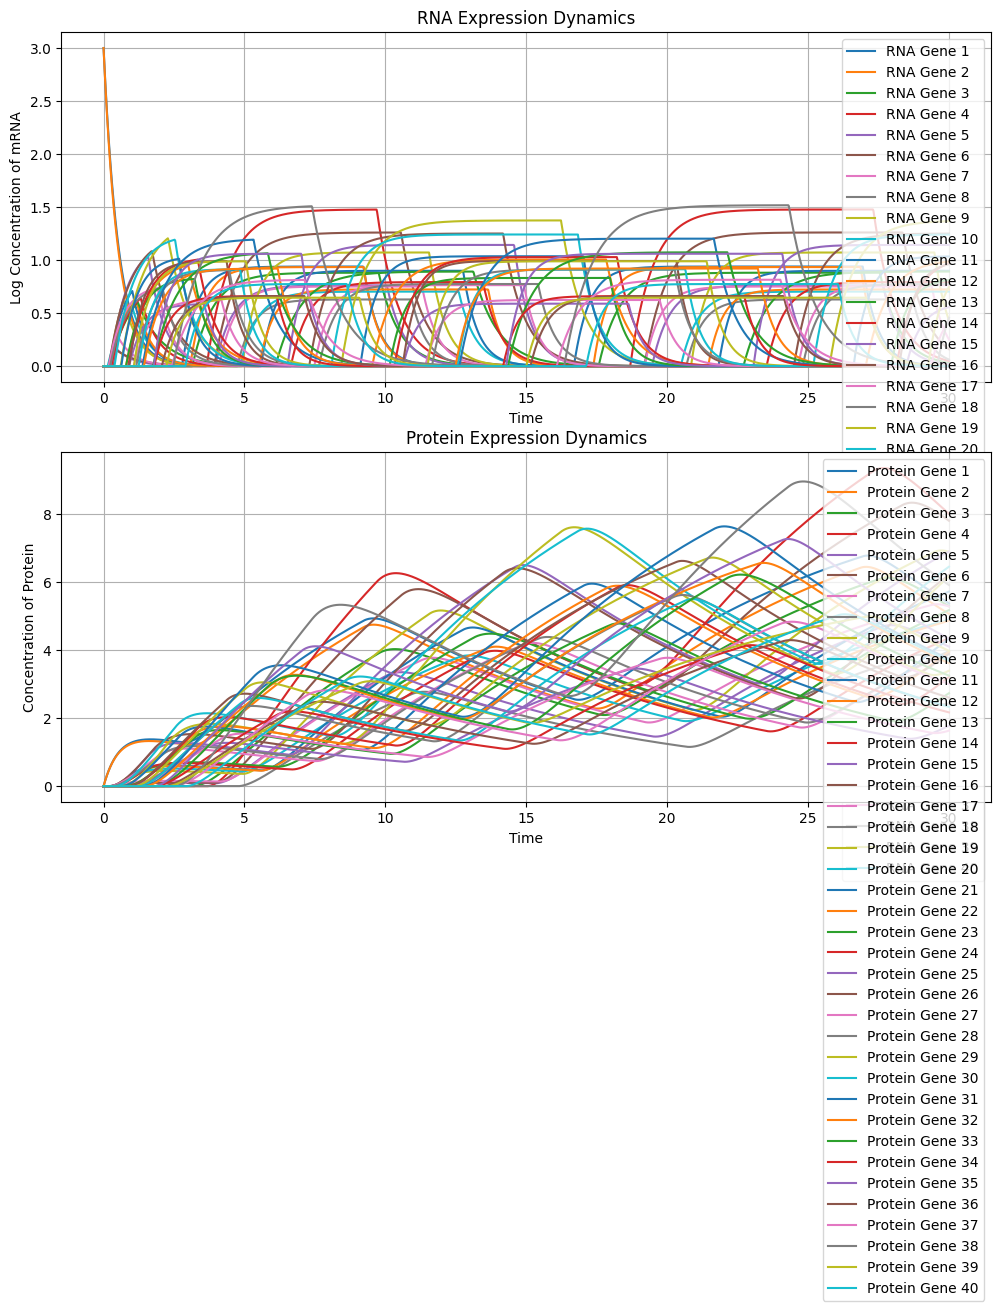

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def generate_sine_interaction_matrix_and_parameters(n):
    """
    Generates an interaction matrix where each row is a sine wave with a period equal to the number of genes,
    and the phase shift increases uniformly across rows. Also generates initial concentrations, transcription rates,
    and splicing rates for each gene.
    
    Parameters:
    n (int): Number of genes (and thus the period of the sine wave).
    
    Returns:
    tuple: Tuple containing:
        - interaction_matrix (numpy array): The sine wave-based interaction matrix.
        - u0 (numpy array): Initial concentrations of unspliced RNA for each gene.
        - beta (numpy array): Transcription rates for each gene.
        - s (numpy array): Splicing rates for each gene.
    """
    # Interaction matrix initialization
    interaction_matrix = np.zeros((n, n))
    x = np.linspace(0, 2 * np.pi, n)  # Period spanning one complete sine wave
    
    # Generate interaction matrix with varying phase shifts
    for i in range(n):
        phase_shift = -(2 * np.pi / n) * i  # Uniform phase shifts across rows
        interaction_matrix[i, :] = np.sin(x + phase_shift)

    interaction_matrix = 2.5 * 40 /n * interaction_matrix  # Scale interaction matrix

    # add some random noise to the matrix
    interaction_matrix += 0.5 * (40/n) * np.random.randn(n, n)
    
    # Initialize parameters: u0, beta, s
    u0 = np.zeros(n)  # Random initial concentrations between 0 and 10
    u0[:2] = 3
    beta = np.random.rand(n) * 1 + 1  # Random transcription rates between 1 and 3
    s = np.random.rand(n) * 1 + 1  # Random splicing rates between 0.1 and 0.6



    return interaction_matrix, u0, beta, s

# Example usage
n = 40 # Number of genes
interactions, u0, beta, s = generate_sine_interaction_matrix_and_parameters(n)

# Optionally, visualize the interaction matrix
plt.imshow(interactions, cmap='RdBu', aspect='auto')
plt.colorbar(label='Interaction Strength')
plt.title('Sine Wave Interaction Matrix')
plt.xlabel('Gene Index')
plt.ylabel('Gene Index')
plt.show()

X=simulate_and_plot_gene_expression(u0, beta, s, interactions, t_end=30, num_points=1500, thresh=2.0)

In [6]:
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import random
import seaborn as sns
import scanpy as sc
import scanpy.external as sce
import scipy.stats as ssa

from pathlib import Path
from ripser import ripser
from scipy.spatial import distance
from tqdm import tqdm

import chunter as chnt
import ringity as rng

from sklearn.metrics import silhouette_score

RANDOM_STATE = 240308

In [7]:
X = X['rna_levels']

In [8]:
# make an anndata object using X as the data matrix
adata = sc.AnnData(X[:,:])

adata

AnnData object with n_obs × n_vars = 1500 × 40

Correlation coefficient: 0.8794576811499056


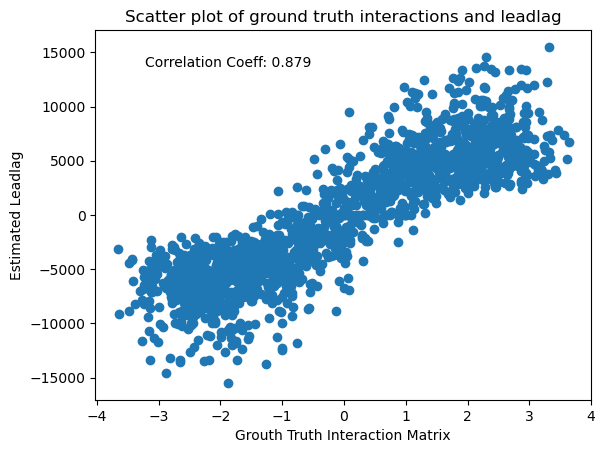

In [39]:
#  create a list of genes with greater than 0.07 gene_amp i.e. the significant genes
gene_list = list(adata.var_names[np.where(adata.var['gene_amp'] > 0.05)])

# convert to a list of ints
gene_list = [int(i) for i in gene_list]

# flatten interactions matrix
interactions_flat = interactions[gene_list, :][:, gene_list].flatten()

# flatten leadlag matrix
leadlag_flat = adata.uns['leadlag'][gene_list,:][:,gene_list].flatten()

# plot scatter plot
plt.scatter(interactions_flat, leadlag_flat)
plt.xlabel('Grouth Truth Interaction Matrix')
plt.ylabel('Estimated Leadlag')
plt.title('Scatter plot of ground truth interactions and leadlag')

# plot the correlation coefficient
correlation = np.corrcoef(interactions_flat, leadlag_flat)[0, 1]
print(f'Correlation coefficient: {correlation}')

# add correlation to plot
plt.text(0.1, 0.9, f'Correlation Coeff: {correlation:.3f}', transform=plt.gca().transAxes)
plt.show()

In [9]:
import numpy as np
from scipy.stats import nbinom

def sample_negative_binomial(X, r):
    # Step 1: Calculate mu as exp(X)
    mu = np.exp(X)
    
    # Step 2: Calculate success probability p (should be between 0 and 1)
    p = r / (r + mu)
    
    # Debug: Print or check the range of p
    if np.any(p <= 0) or np.any(p >= 1):
        print("Error: p out of bounds", p)
        raise ValueError("Invalid success probability 'p' encountered.")

    # Step 3: Sample from the Negative Binomial distribution
    nb_samples = nbinom.rvs(r, p, size=X.shape)

    return nb_samples

# Example usage
r = 100  # Dispersion parameter
nb_samples = sample_negative_binomial(X[:,:], r)

In [10]:
nb_samples.shape

(1500, 40)

In [12]:
adata2 = sc.AnnData(nb_samples)

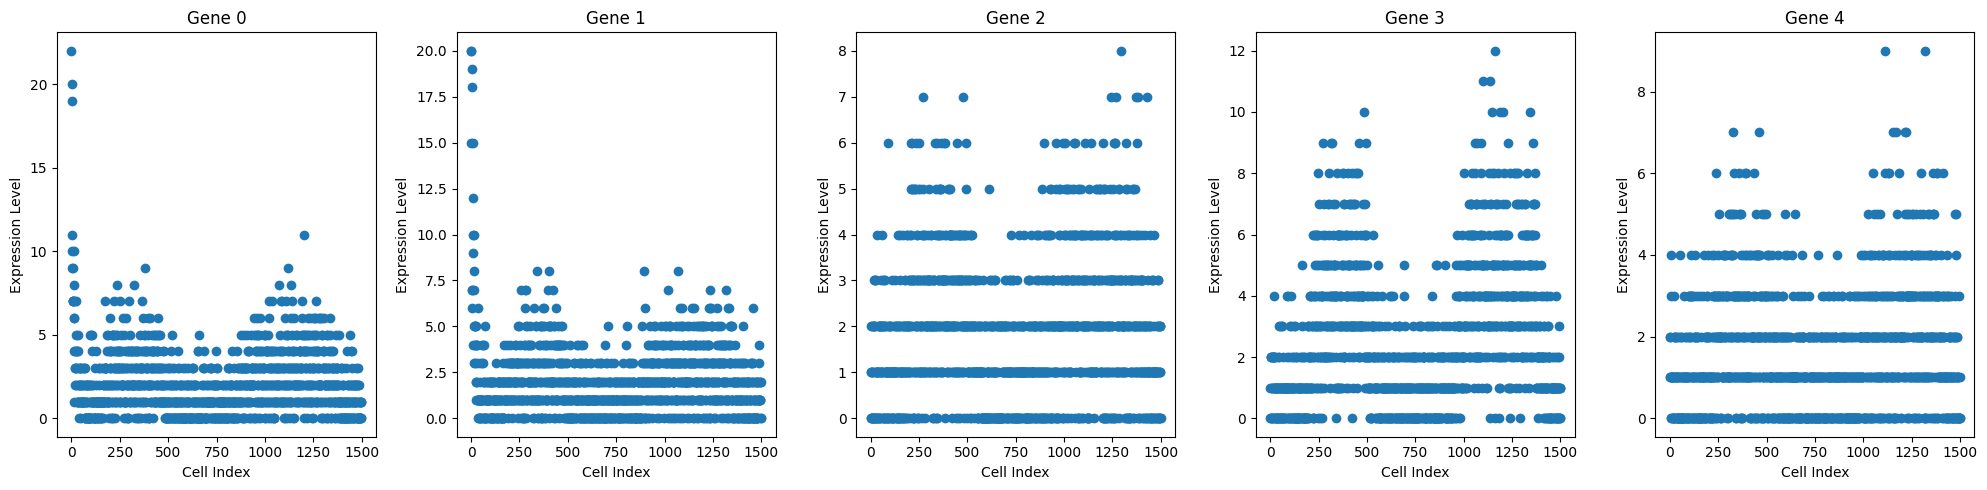

In [14]:
# plot the first 10 genes against the index of the cell on a scatter plo


# can you do this so you put the first 5 genes on a panel together
fig, axs = plt.subplots(1, 5, figsize=(20, 5))

for i in range(5):
    axs[i].scatter(np.arange(adata2.shape[0]), adata2.X[:, i])
    axs[i].set_title('Gene ' + str(i))
    axs[i].set_xlabel('Cell Index')
    axs[i].set_ylabel('Expression Level')

plt.tight_layout()
plt.show()


In [15]:
sc.pp.filter_cells(adata2, min_genes =1)
sc.pp.filter_genes(adata2, min_cells=3)

# Log transform the data and scale
sc.pp.log1p(adata2)

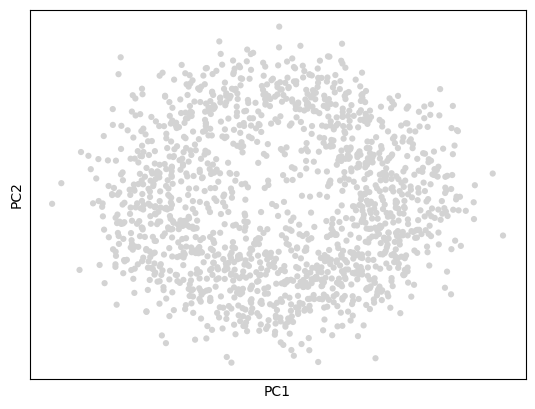

In [17]:
sc.pl.pca(adata2)

In [18]:
adata2

AnnData object with n_obs × n_vars = 1500 × 40
    obs: 'n_genes'
    var: 'n_cells'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [19]:
chnt.circular(adata2, comp = [0,1,2])

/Users/maggs/Documents/code/cocycle-hunter/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/maggs/Documents/code/cocycle-hunter/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/maggs/Documents/code/cocycle-hunter/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.071196645


/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:97: RuntimeWarning: divide by zero encountered in matmul
  W = G @ P_inv
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:97: RuntimeWarning: overflow encountered in matmul
  W = G @ P_inv
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:97: RuntimeWarning: invalid value encountered in matmul
  W = G @ P_inv
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:99: RuntimeWarning: divide by zero encountered in matmul
  L_w = P_inv @ (np.diag(D * P) - G) @ P_inv
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:99: RuntimeWarning: overflow encountered in matmul
  L_w = P_inv @ (np.diag(D * P) - G) @ P_inv
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:99: RuntimeWarning: invalid value encountered in matmul
  L_w = P_inv @ (np.diag(D * P) - G) @ P_inv


AnnData object with n_obs × n_vars = 1500 × 40
    obs: 'n_genes', 'coords', 'log_counts'
    var: 'n_cells'
    uns: 'log1p', 'pca', 'circular'
    obsm: 'X_pca'
    varm: 'PCs'

In [20]:
chnt.leadlag(adata2)

/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:350: RuntimeWarning: divide by zero encountered in matmul
  harmonic_center = harmonic.T @ barycenters
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:350: RuntimeWarning: overflow encountered in matmul
  harmonic_center = harmonic.T @ barycenters
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:350: RuntimeWarning: invalid value encountered in matmul
  harmonic_center = harmonic.T @ barycenters


Harmonic Recentering
Calculating Leadlag Matrix


  0%|          | 0/40 [00:00<?, ?it/s]/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:542: RuntimeWarning: divide by zero encountered in matmul
  ll[i, j] = 0.5 * np.linalg.det(PQ[:, [i, j], :]).T @ harm
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:542: RuntimeWarning: overflow encountered in matmul
  ll[i, j] = 0.5 * np.linalg.det(PQ[:, [i, j], :]).T @ harm
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:542: RuntimeWarning: invalid value encountered in matmul
  ll[i, j] = 0.5 * np.linalg.det(PQ[:, [i, j], :]).T @ harm
100%|██████████| 40/40 [00:02<00:00, 19.52it/s]

Calculating Spectral Information
Aligning Data
Estimated starting gene: 3
Phase correction: 3.141592653589793 rad



/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:176: RuntimeWarning: divide by zero encountered in matmul
  scores = X.T @ target
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:176: RuntimeWarning: overflow encountered in matmul
  scores = X.T @ target
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:176: RuntimeWarning: invalid value encountered in matmul
  scores = X.T @ target


AnnData object with n_obs × n_vars = 1500 × 40
    obs: 'n_genes', 'coords', 'log_counts'
    var: 'n_cells', 'gene_phase', 'gene_amp'
    uns: 'log1p', 'pca', 'circular', 'leadlag', 'leadlag_eigvals'
    obsm: 'X_pca'
    varm: 'PCs', 'leadlag_pcs'
    layers: 'h_recenter'

/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1016: RuntimeWarning: divide by zero encountered in matmul
  proj_re = adata.X @ re
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1016: RuntimeWarning: overflow encountered in matmul
  proj_re = adata.X @ re
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1016: RuntimeWarning: invalid value encountered in matmul
  proj_re = adata.X @ re
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1017: RuntimeWarning: divide by zero encountered in matmul
  proj_im = adata.X @ im
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1017: RuntimeWarning: overflow encountered in matmul
  proj_im = adata.X @ im
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1017: RuntimeWarning: invalid value encountered in matmul
  proj_im = adata.X @ im


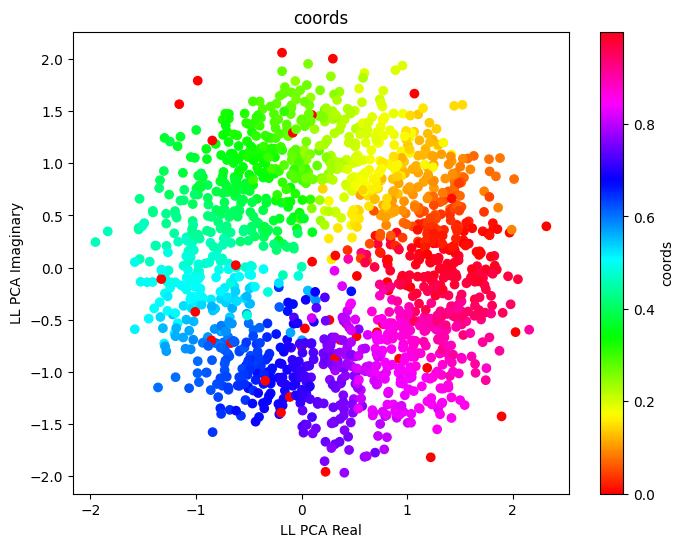

In [21]:
chnt.plot_2d(adata2, c = 'coords', mode = 'll')

In [28]:
#chnt.reverse(adata2)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very l

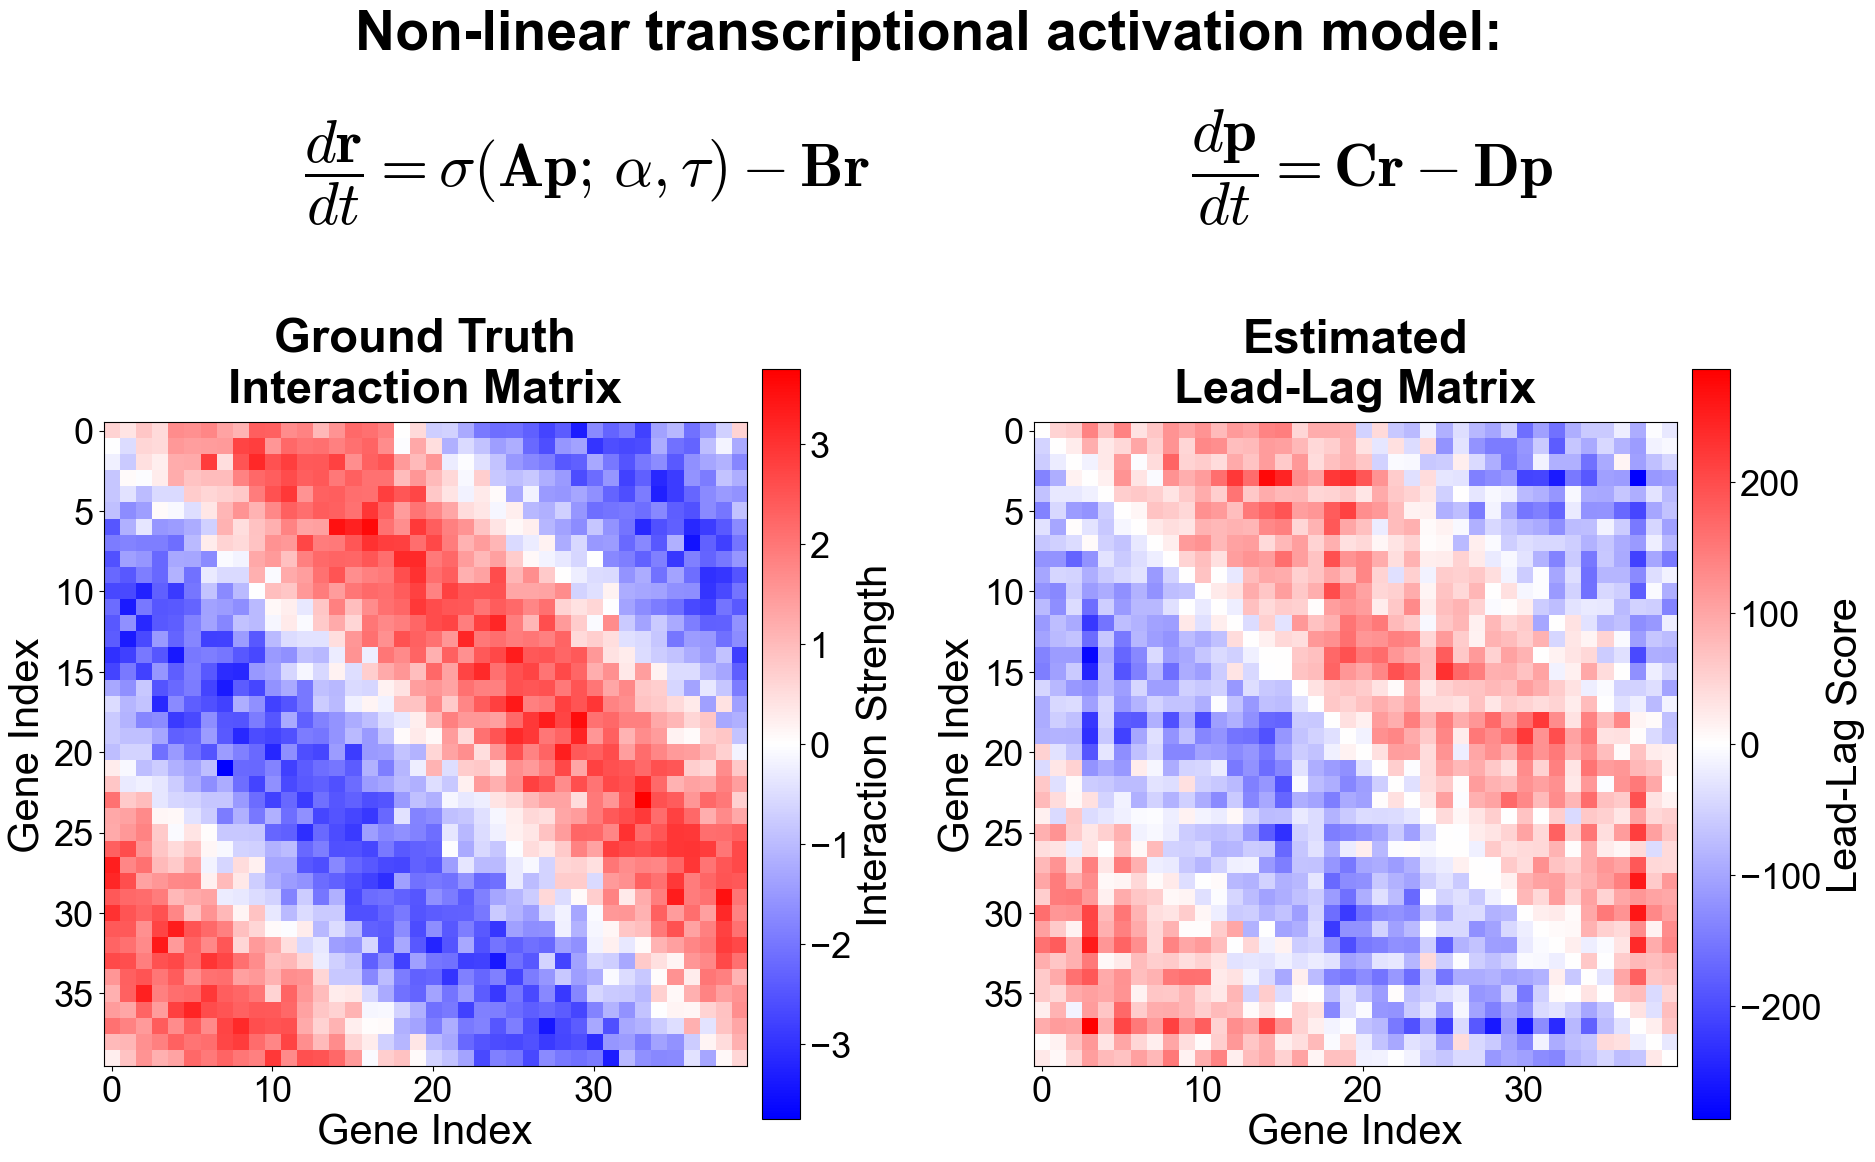

In [41]:
import matplotlib.pyplot as plt
import matplotlib.text
import numpy as np

plt.rcParams.update({
    "font.family": "Arial",
    "pdf.fonttype": 42,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "mathtext.fontset": "cm",
})

leadlag = adata2.uns['leadlag']

# Symmetric color limits for both panels
vmax_gt = np.abs(interactions).max()
vmax_ll = np.abs(leadlag).max()

fig, axes = plt.subplots(1, 2, figsize=(22, 14))

# Leave space at the top for the equation
fig.subplots_adjust(top=0.78)

# --- Title and equation at the top ---
fig.text(0.5, 0.97,
         'Non-linear transcriptional activation model:',
         ha='center', va='top', fontsize=40, fontweight='bold',
         fontfamily='Arial')

fig.text(0.5, 0.90,
         r'$\dfrac{d\mathbf{r}}{dt} = \sigma(\mathbf{A}\mathbf{p};\,\alpha,\tau) - \mathbf{B}\mathbf{r}'
         r'\qquad\qquad\qquad'
         r'\dfrac{d\mathbf{p}}{dt} = \mathbf{C}\mathbf{r} - \mathbf{D}\mathbf{p}$',
         ha='center', va='top', fontsize=44)

# --- Left panel: Ground Truth Interaction Matrix ---
im0 = axes[0].imshow(interactions, cmap='bwr', aspect='equal', interpolation='nearest',
                      vmin=-vmax_gt, vmax=vmax_gt)
cbar0 = plt.colorbar(im0, ax=axes[0], shrink=0.8, pad=0.02)
cbar0.set_label('Interaction Strength', fontsize=30)
cbar0.ax.tick_params(labelsize=26)
axes[0].set_title('Ground Truth\nInteraction Matrix', fontsize=34, fontweight='bold', pad=15)
axes[0].set_xlabel('Gene Index', fontsize=30)
axes[0].set_ylabel('Gene Index', fontsize=30)
axes[0].tick_params(labelsize=26)

# --- Right panel: Lead-Lag Matrix ---
im1 = axes[1].imshow(leadlag, cmap='bwr', aspect='equal', interpolation='nearest',
                      vmin=-vmax_ll, vmax=vmax_ll)
cbar1 = plt.colorbar(im1, ax=axes[1], shrink=0.8, pad=0.02)
cbar1.set_label('Lead-Lag Score', fontsize=30)
cbar1.ax.tick_params(labelsize=26)
axes[1].set_title('Estimated\nLead-Lag Matrix', fontsize=34, fontweight='bold', pad=15)
axes[1].set_xlabel('Gene Index', fontsize=30)
axes[1].set_ylabel('Gene Index', fontsize=30)
axes[1].tick_params(labelsize=26)

# Force all text to black
for obj in fig.findobj(matplotlib.text.Text):
    obj.set_color('black')

plt.savefig('./figures/synthetic-interaction-vs-leadlag.pdf', dpi=600, bbox_inches='tight')
plt.savefig('/Users/maggs/Documents/chunter figures/NEW/FIGURE 2/synthetic-interaction-vs-leadlag.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [36]:
adata2.uns['leadlag']

array([[   0.        ,   48.89739233,   57.79767171, ...,  -93.29377537,
          -3.68487708,  -25.78592671],
       [ -48.89739233,    0.        ,   20.30563127, ..., -111.51758992,
         -14.29939771,   -7.56614195],
       [ -57.79767171,  -20.30563127,    0.        , ..., -105.59855778,
         -70.96367591,  -44.92120681],
       ...,
       [  93.29377537,  111.51758992,  105.59855778, ...,    0.        ,
          18.6208526 ,   64.43441359],
       [   3.68487708,   14.29939771,   70.96367591, ...,  -18.6208526 ,
           0.        ,  -26.63769145],
       [  25.78592671,    7.56614195,   44.92120681, ...,  -64.43441359,
          26.63769145,    0.        ]], shape=(40, 40))

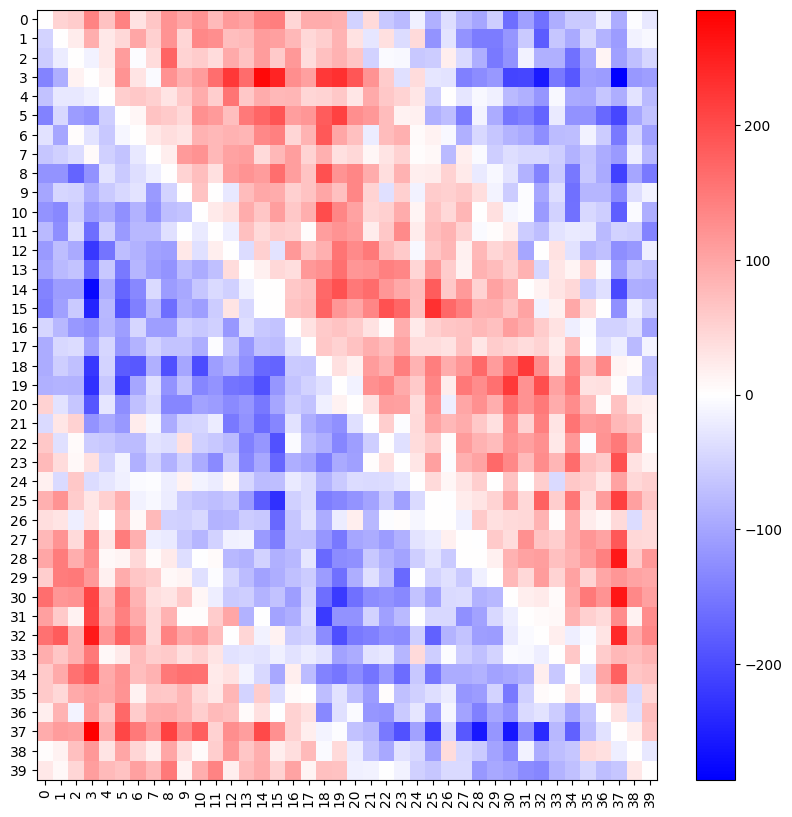

In [30]:
chnt.leadlag_plot(adata2, k=40, genes = np.arange(40).astype(str))
plt.savefig('./figures/synthetic-leadlag_plot.pdf', dpi=600, bbox_inches='tight')
plt.savefig('/Users/maggs/Documents/chunter figures/NEW/FIGURE 2/synthetic-leadlag-plot.pdf', dpi=600, bbox_inches='tight')
plt.show()

/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:813: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


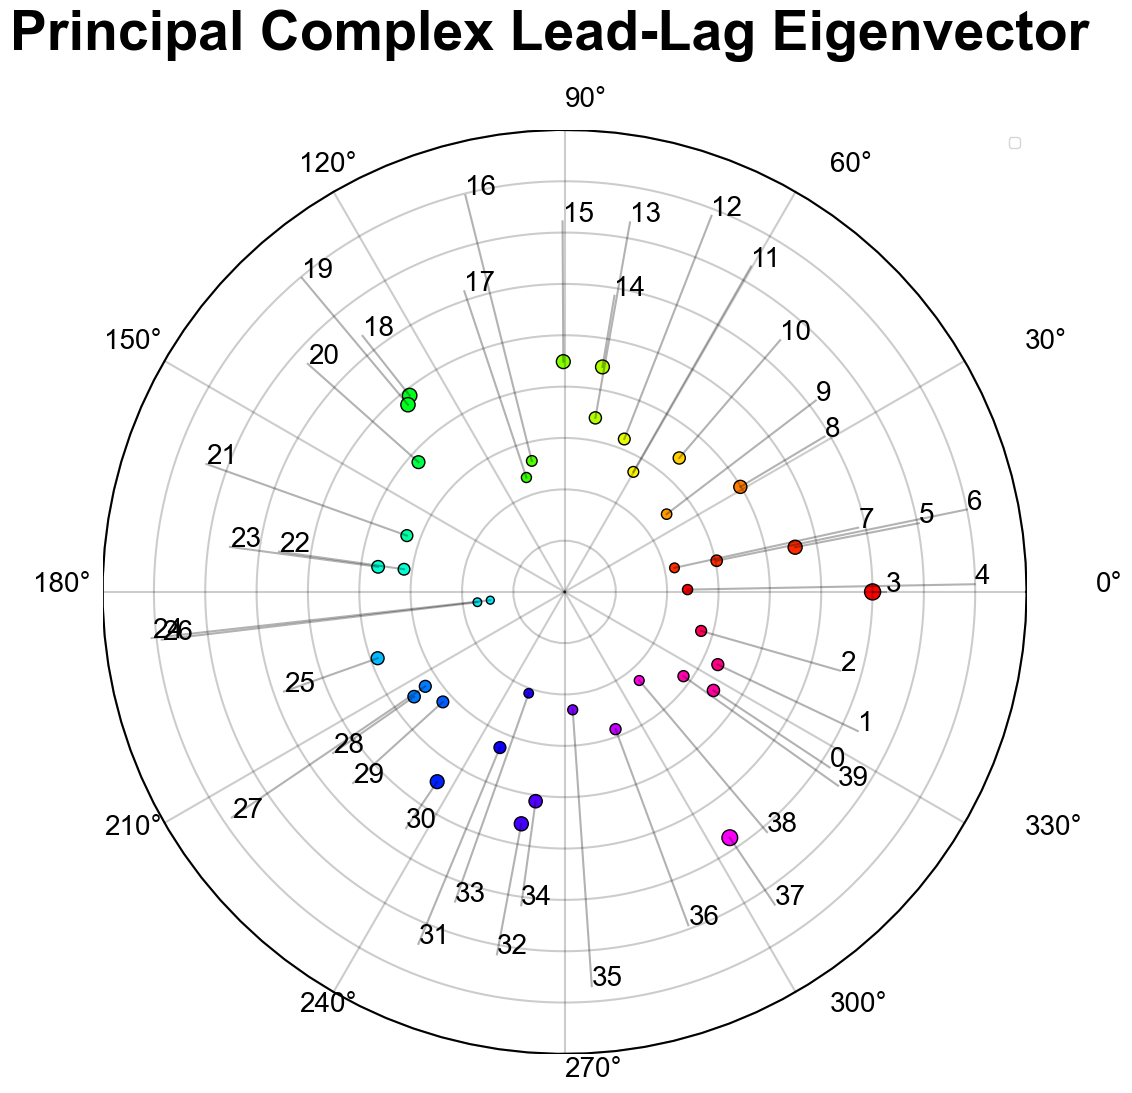

In [48]:
import matplotlib.pyplot as plt
import matplotlib.text

plt.rcParams.update({
    "font.family": "Arial",
    "pdf.fonttype": 42,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

# Temporarily prevent plt.show() from clearing the figure
_orig_show = plt.show
plt.show = lambda *a, **kw: None

chnt.phase_plot(adata2, topk=40, scale=1.0)

# Get the current figure and axis
fig = plt.gcf()
ax = plt.gca()

# Add title
fig.suptitle('Principal Complex Lead-Lag Eigenvector', fontsize=40,
             fontweight='bold', fontfamily='Arial', y=0.98)

# Update all text in the figure to Arial and bigger sizes
for obj in fig.findobj(matplotlib.text.Text):
    obj.set_fontfamily('Arial')
    obj.set_color('black')
    current_size = obj.get_fontsize()
    # Scale up the gene labels and angle labels
    if current_size <= 10:
        obj.set_fontsize(20)
    elif current_size <= 12:
        obj.set_fontsize(26)

fig.set_size_inches(12, 12)

plt.savefig('./figures/synthetic-phase-plot.pdf', dpi=600, bbox_inches='tight')
plt.savefig('/Users/maggs/Documents/chunter figures/NEW/FIGURE 2/synthetic-phase-plot.pdf', dpi=600, bbox_inches='tight')

plt.show = _orig_show  # restore
plt.show()

/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1016: RuntimeWarning: divide by zero encountered in matmul
  proj_re = adata.X @ re
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1016: RuntimeWarning: overflow encountered in matmul
  proj_re = adata.X @ re
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1016: RuntimeWarning: invalid value encountered in matmul
  proj_re = adata.X @ re
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1017: RuntimeWarning: divide by zero encountered in matmul
  proj_im = adata.X @ im
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1017: RuntimeWarning: overflow encountered in matmul
  proj_im = adata.X @ im
/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:1017: RuntimeWarning: invalid value encountered in matmul
  proj_im = adata.X @ im


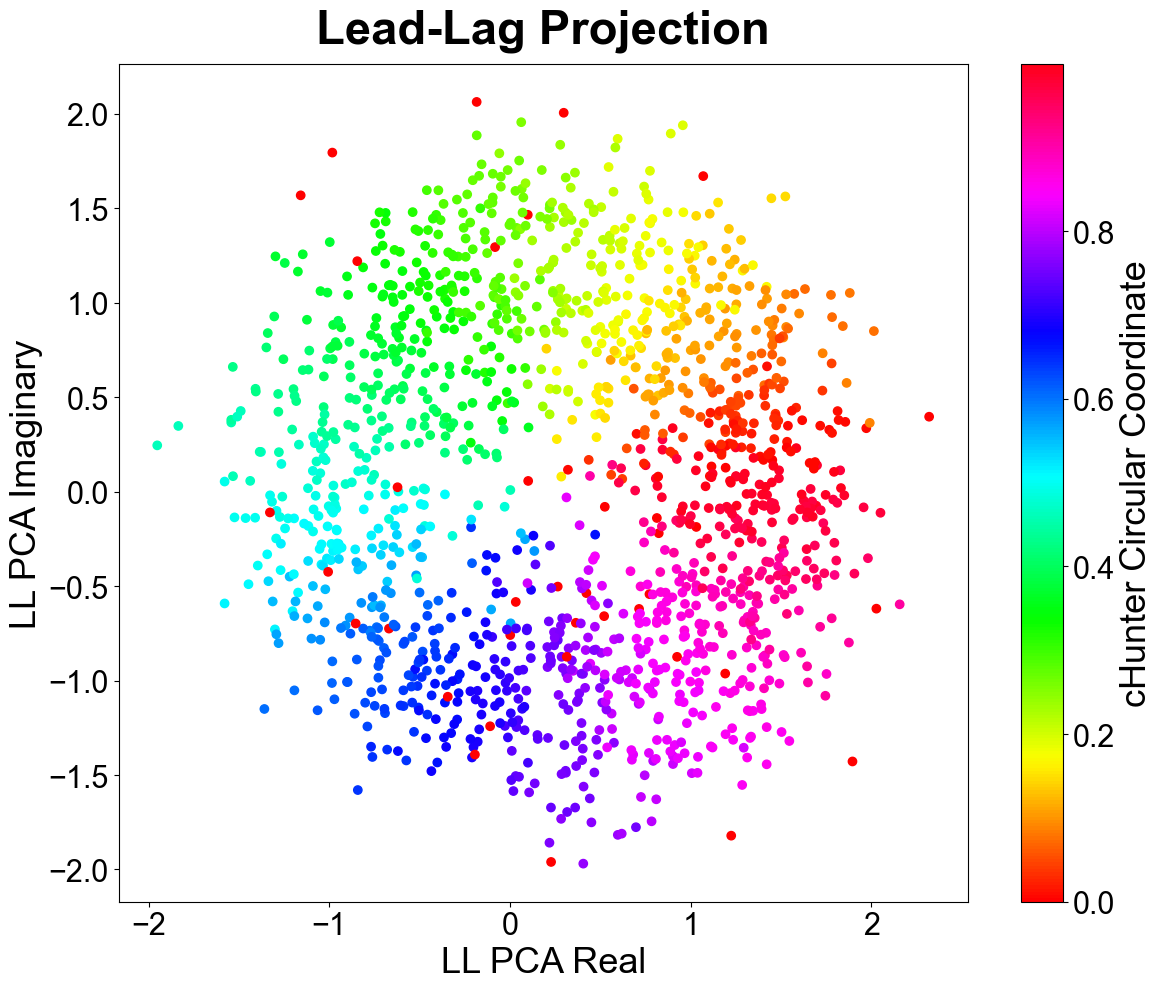

In [49]:
import matplotlib.pyplot as plt
import matplotlib.text

plt.rcParams.update({
    "font.family": "Arial",
    "pdf.fonttype": 42,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

_orig_show = plt.show
plt.show = lambda *a, **kw: None

chnt.plot_2d(adata2, c='coords', mode='ll')

fig = plt.gcf()
ax = fig.axes[0]

# Update title
ax.set_title('Lead-Lag Projection', fontsize=34, fontweight='bold', fontfamily='Arial', pad=15)

# Update axis labels
ax.set_xlabel('LL PCA Real', fontsize=26, fontfamily='Arial')
ax.set_ylabel('LL PCA Imaginary', fontsize=26, fontfamily='Arial')
ax.tick_params(labelsize=22)

# Update colorbar label
if len(fig.axes) > 1:
    cbar_ax = fig.axes[1]
    cbar_ax.set_ylabel('cHunter Circular Coordinate', fontsize=26, fontfamily='Arial')
    cbar_ax.tick_params(labelsize=22)

# Force all text to Arial and black
for obj in fig.findobj(matplotlib.text.Text):
    obj.set_fontfamily('Arial')
    obj.set_color('black')

fig.set_size_inches(12, 10)
plt.tight_layout()

plt.savefig('./figures/synthetic-leadlag_projection.pdf', dpi=600, bbox_inches='tight')
plt.savefig('/Users/maggs/Documents/chunter figures/NEW/FIGURE 2/synthetic-leadlag-projection.pdf', dpi=600, bbox_inches='tight')

plt.show = _orig_show
plt.show()

In [ ]:
#  create a list of genes with greater than 0.07 gene_amp i.e. the significant genes
gene_list = list(adata2.var_names[np.where(adata.var['gene_amp'] > 0.05)])

# convert to a list of ints
gene_list = [int(i) for i in gene_list]

# flatten interactions matrix
interactions_flat = -interactions[gene_list, :][:, gene_list].flatten()

# flatten leadlag matrix
leadlag_flat = adata2.uns['leadlag'][gene_list,:][:,gene_list].flatten()

# plot scatter plot
plt.scatter(interactions_flat, leadlag_flat)
plt.xlabel('Grouth Truth Interaction Matrix')
plt.ylabel('Estimated Leadlag')
plt.title('Scatter plot of ground truth interactions and leadlag')

# plot the correlation coefficient
correlation = np.corrcoef(interactions_flat, leadlag_flat)[0, 1]
print(f'Correlation coefficient: {correlation}')

# add correlation to plot
plt.text(0.1, 0.9, f'Correlation Coeff: {correlation:.3f}', transform=plt.gca().transAxes)
plt.show()

KeyError: 'gene_amp'

/Users/maggs/Documents/code/cocycle-hunter/src/chunter/chunter.py:813: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


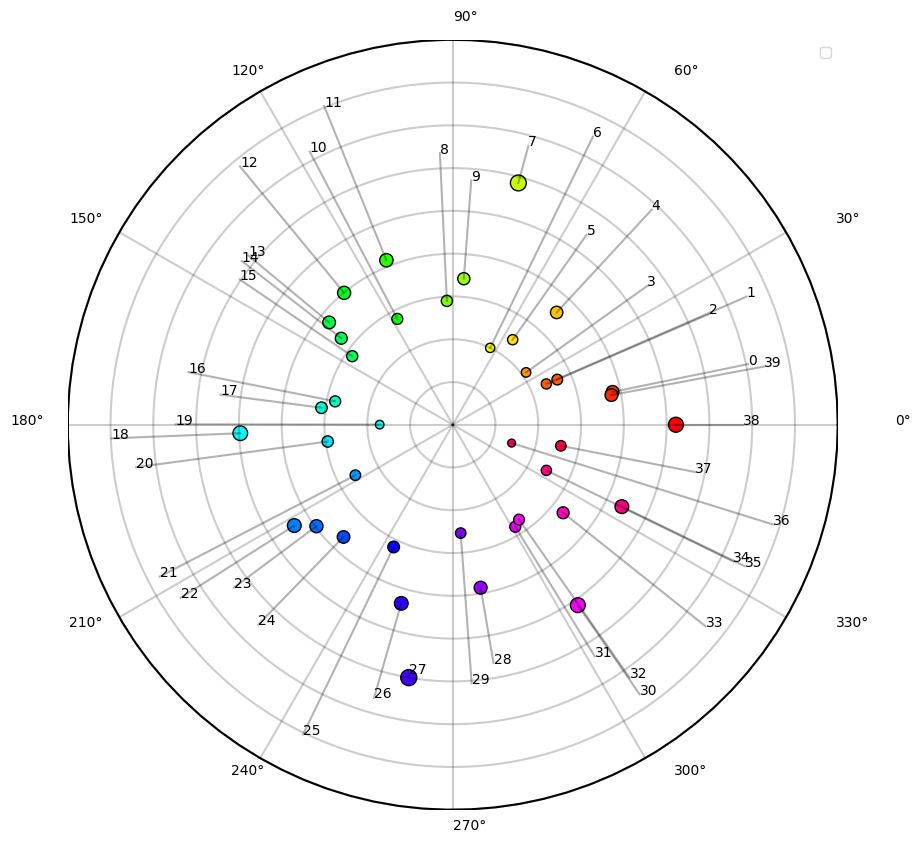

In [26]:
chnt.phase_plot(adata2, topk = 40)

In [8]:
# normalize solution by column
solution_norm = 999*solution / np.max(solution)

# round to nearest integer
solution_norm = np.round(solution_norm)

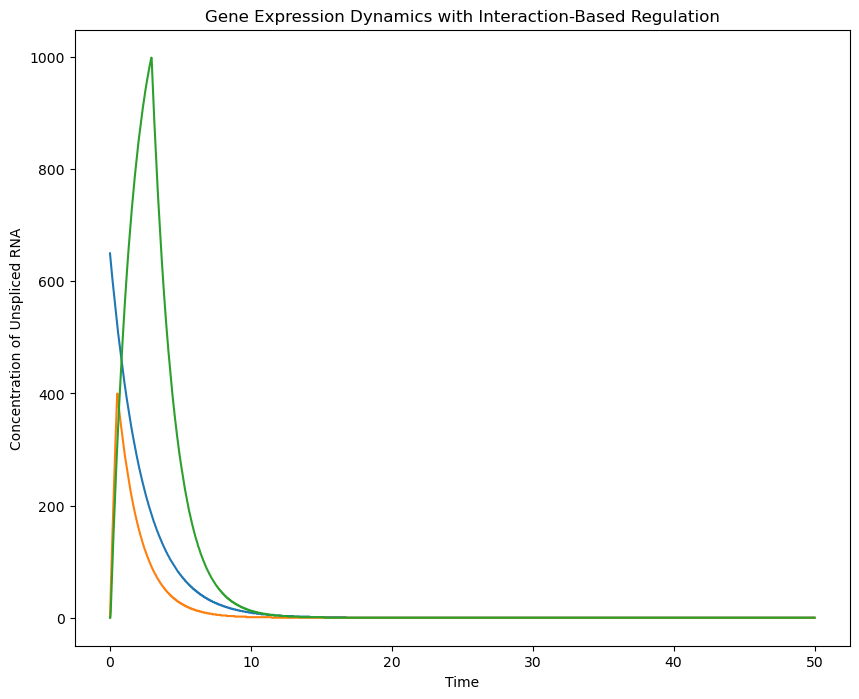

In [9]:
t = np.linspace(0, 50, 2000)
# plot normalized solutio
plt.figure(figsize=(10, 8))
labels = ['Gene' + str(i+1) for i in range(len(u0))]
for i in range(len(u0)):
    plt.plot(t, solution_norm[:, i], label=labels[i])

plt.xlabel('Time')
plt.ylabel('Concentration of Unspliced RNA')
plt.title('Gene Expression Dynamics with Interaction-Based Regulation')
plt.show()

In [10]:
# export solution norm to a text file, where each row is a time point and each column is a gene
# make sure to convert all intergers to 3 digits by padding with zeros
# dont put any spaces in, just the numbers and line breaks for each row

np.savetxt('solution_norm.txt', solution_norm, fmt='%03d', delimiter='')


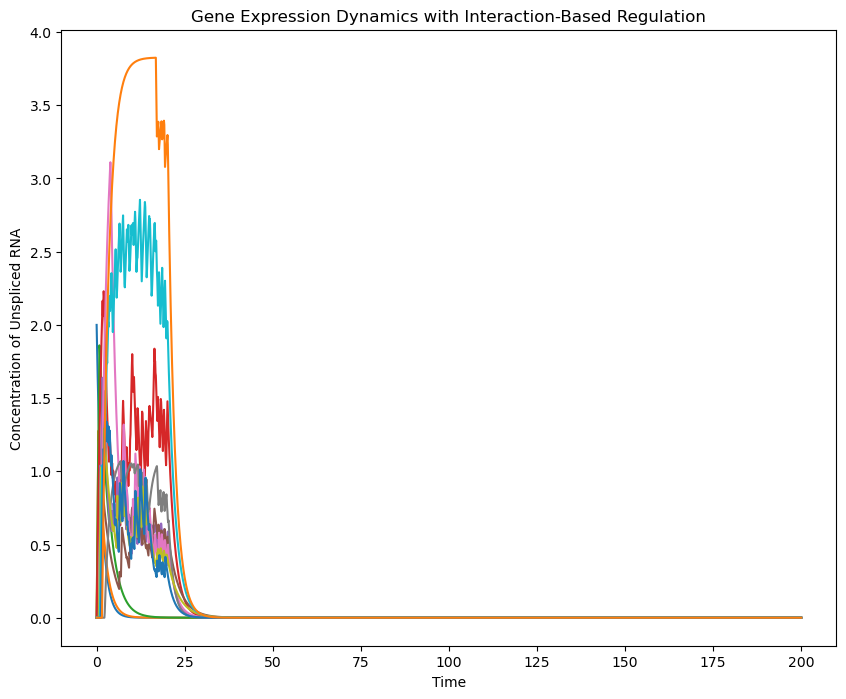

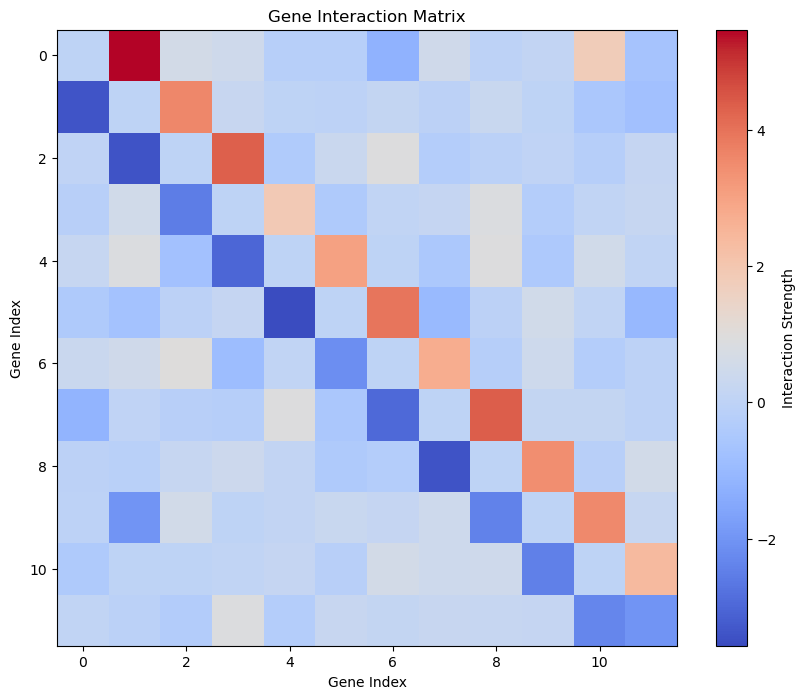

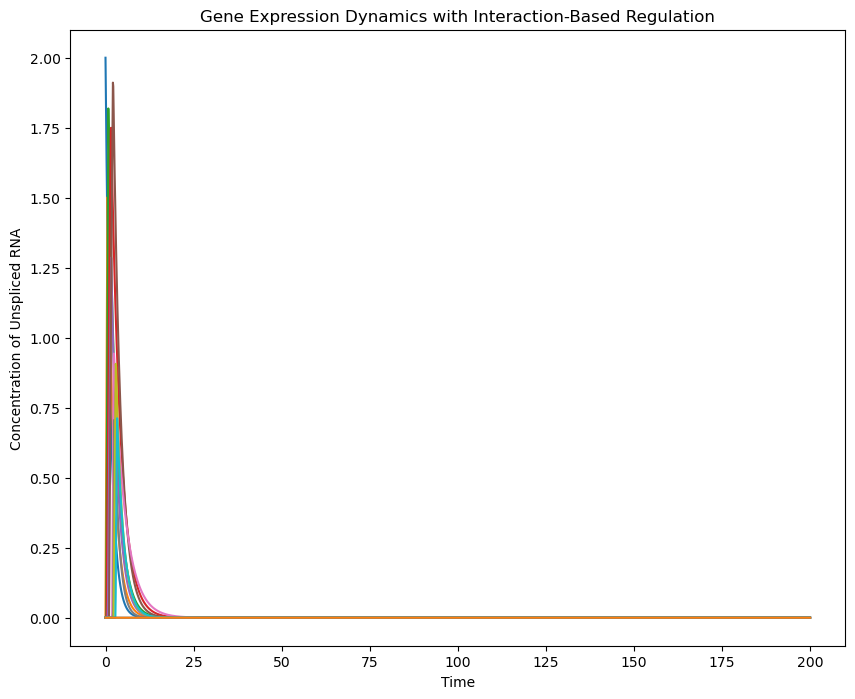

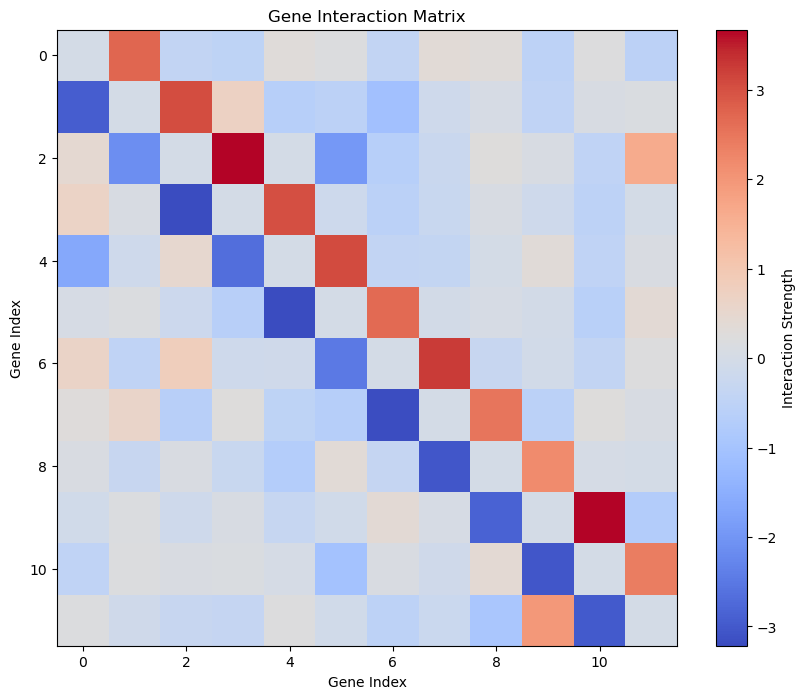

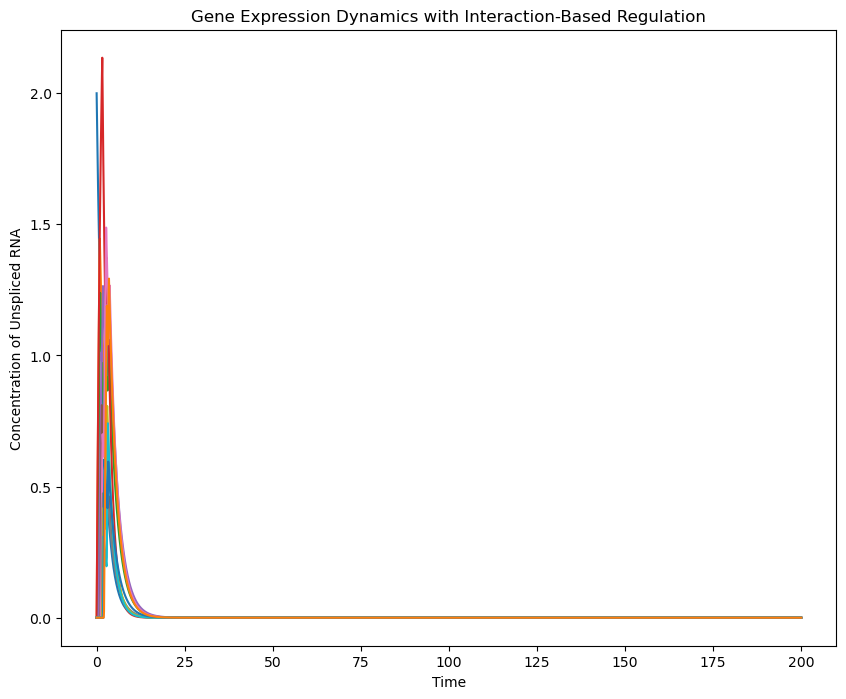

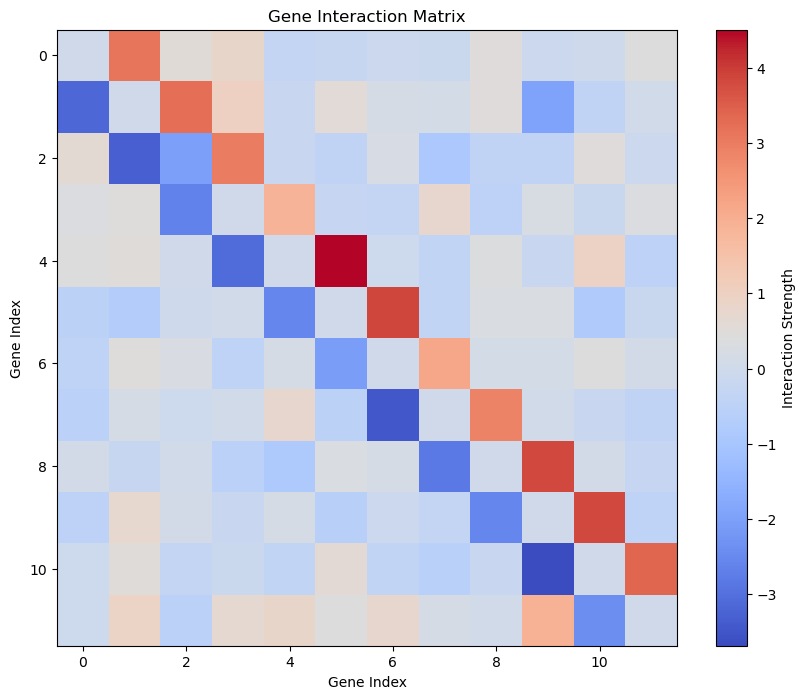

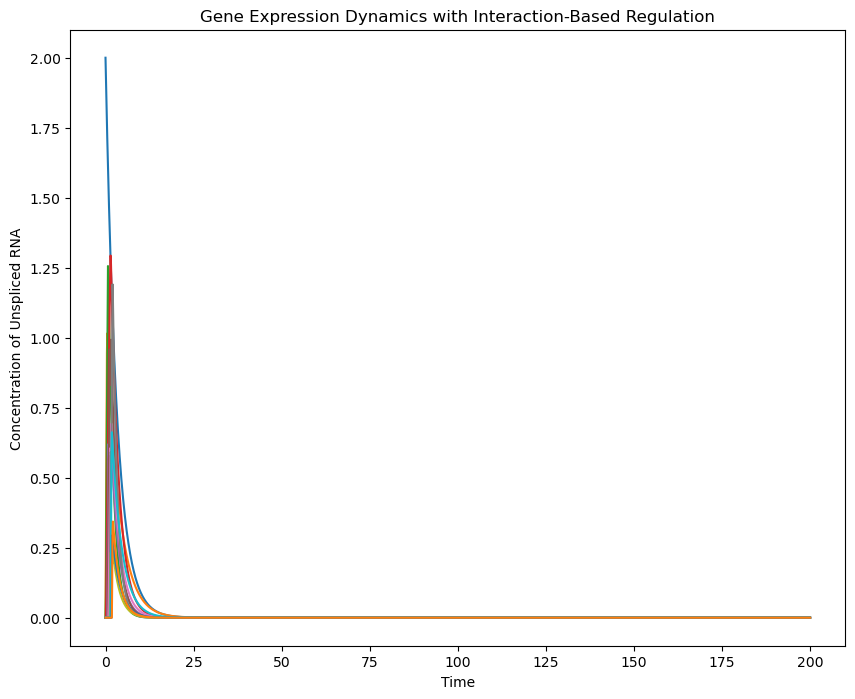

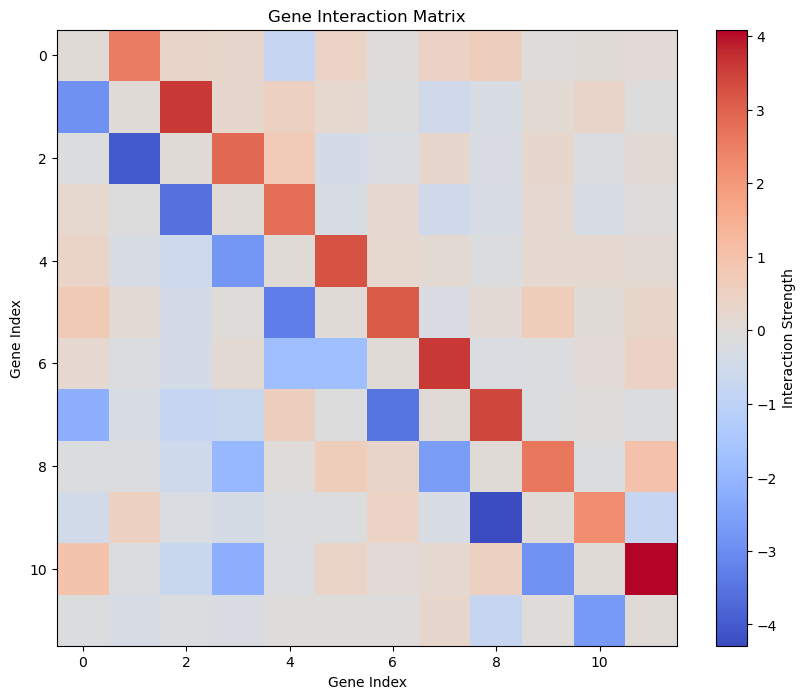

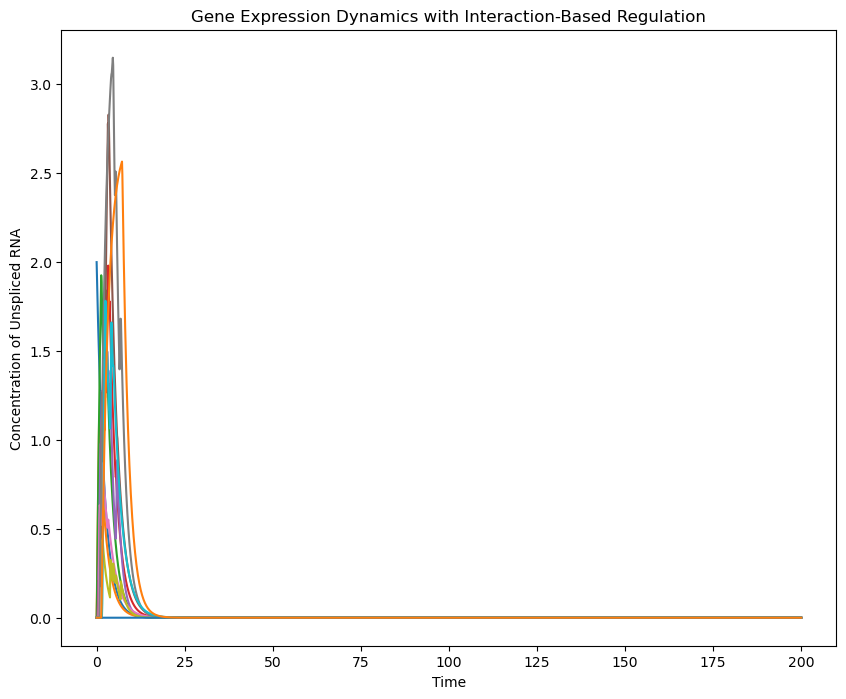

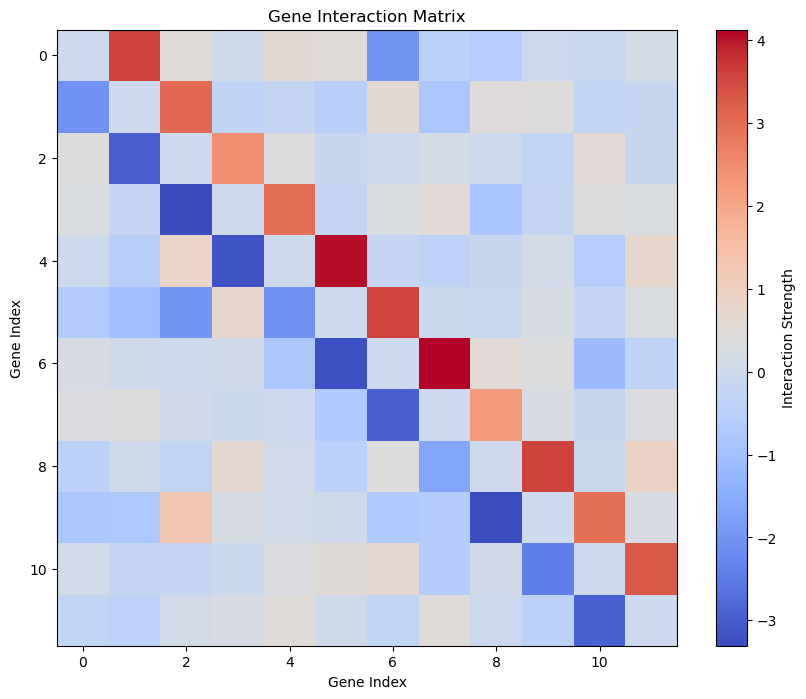

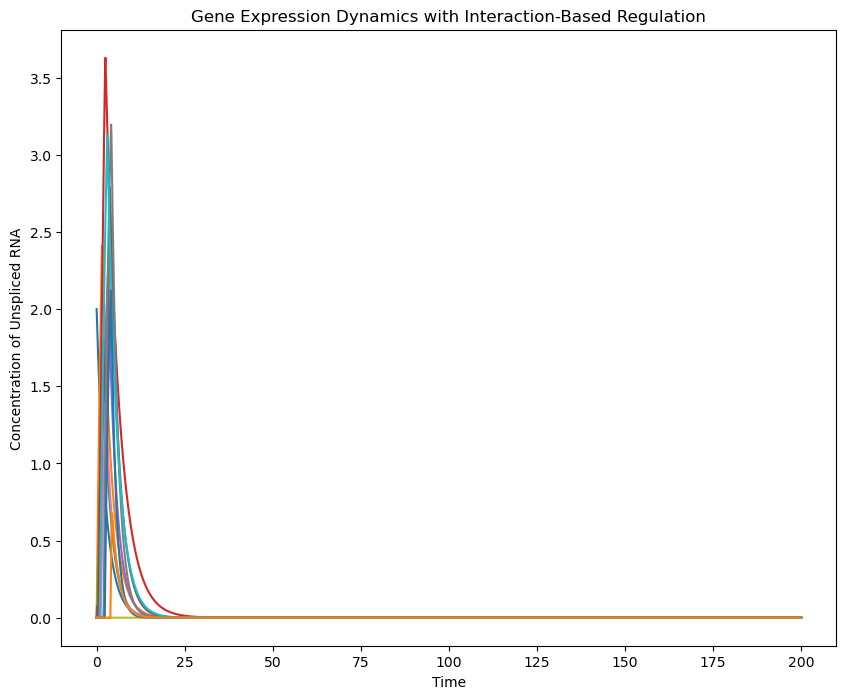

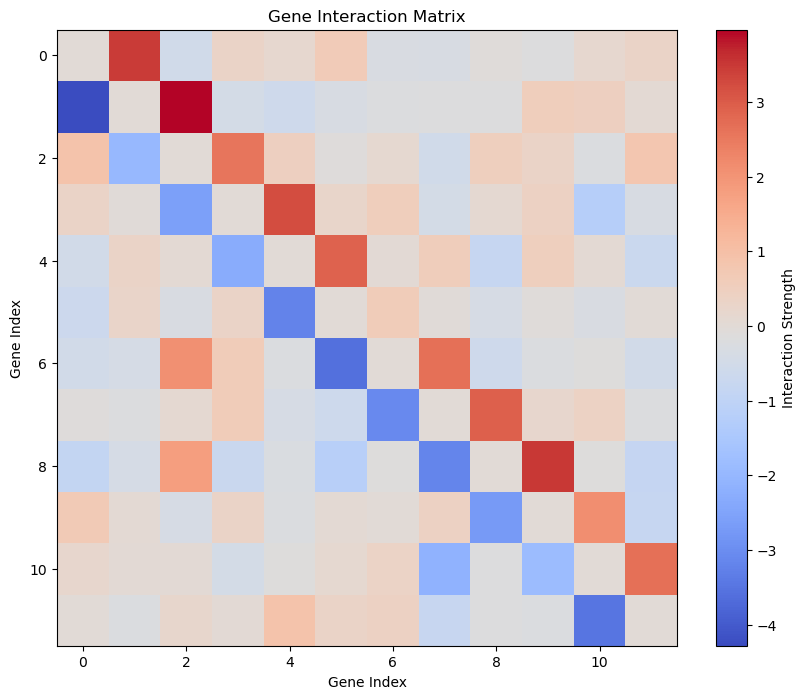

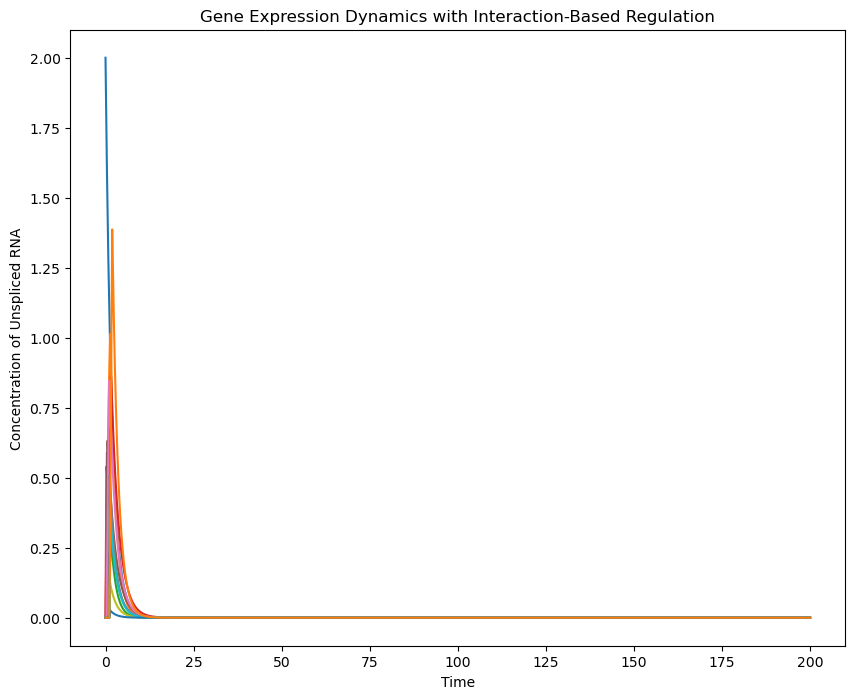

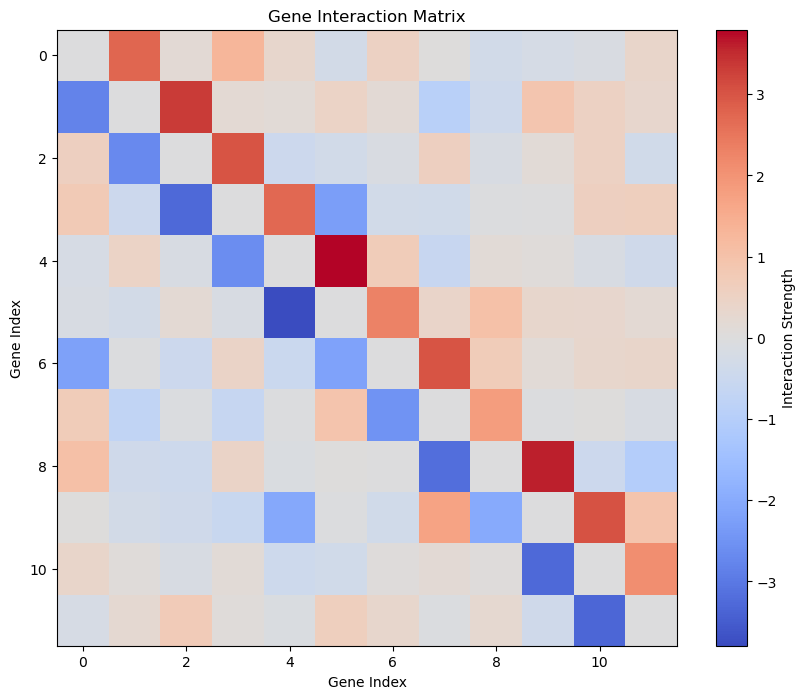

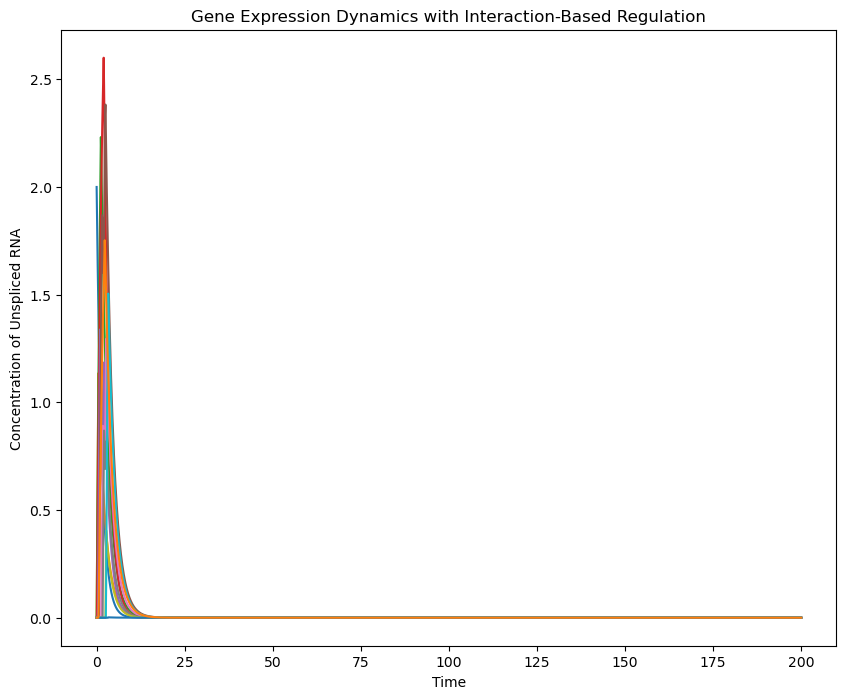

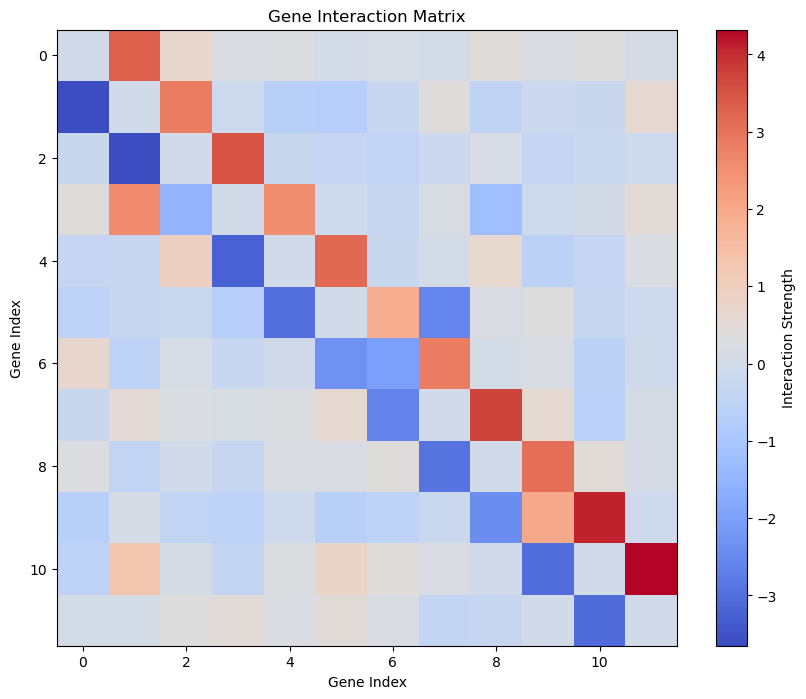

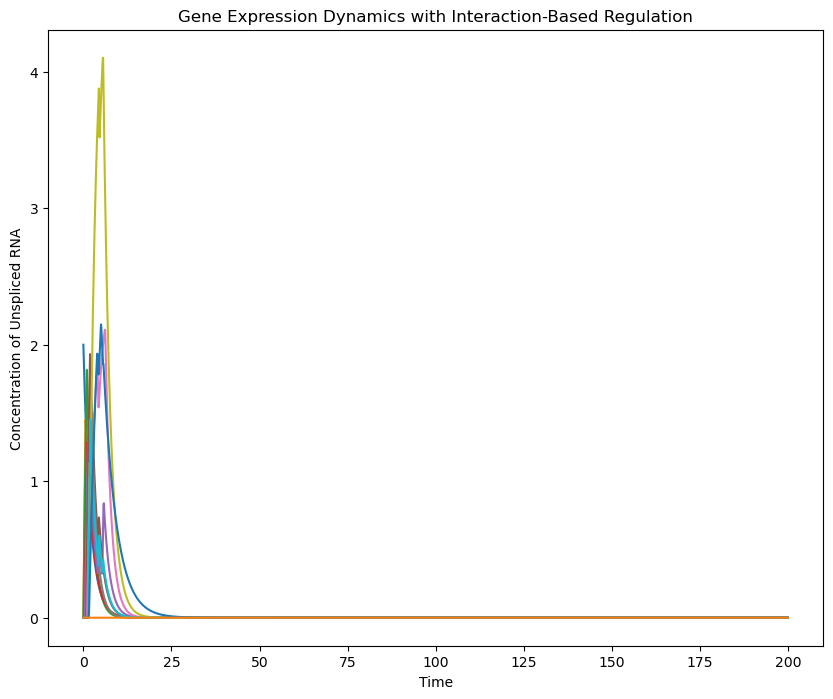

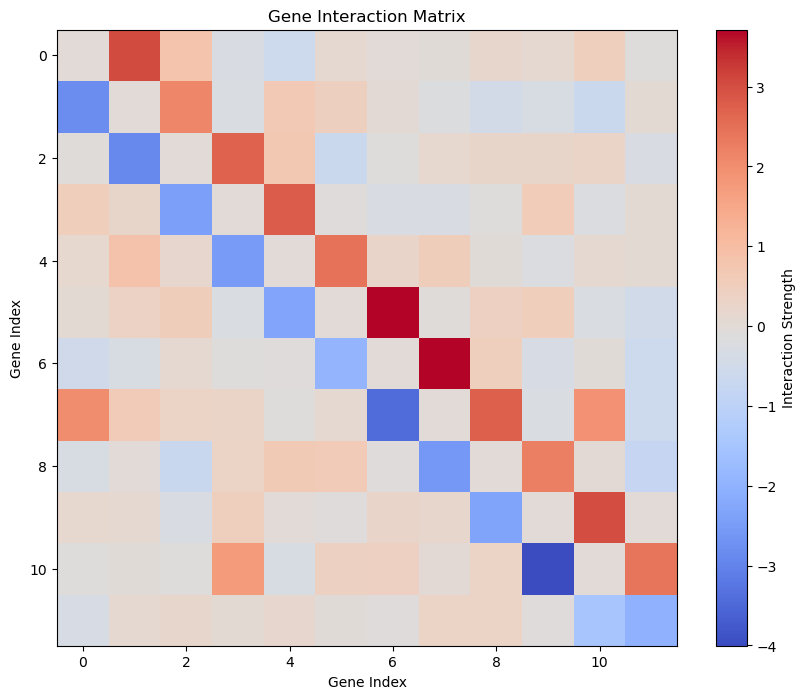

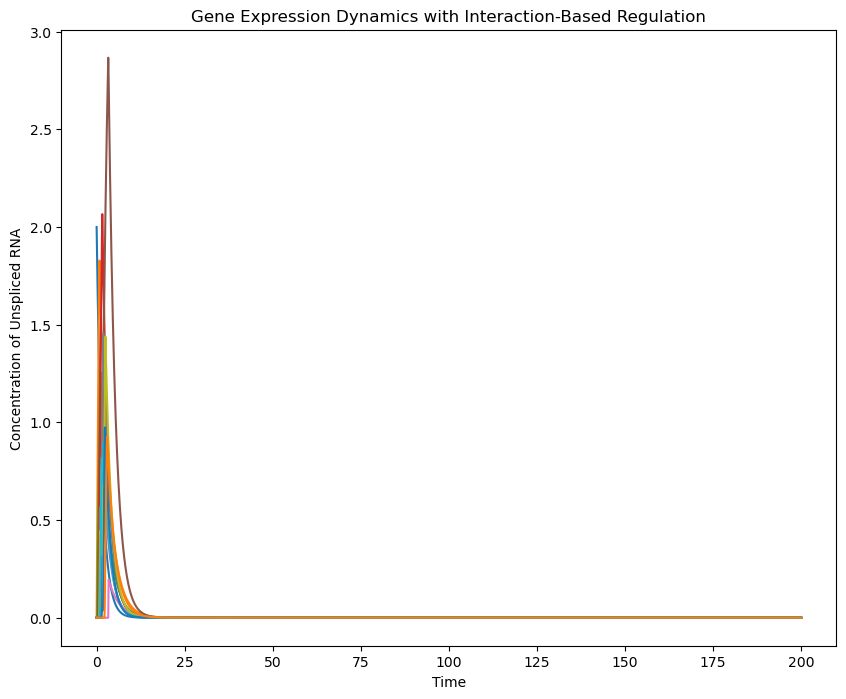

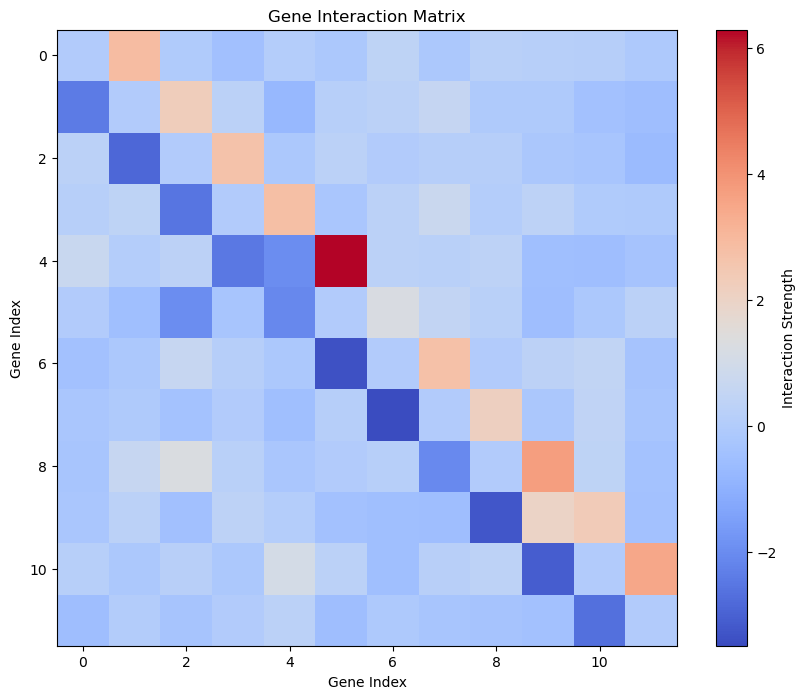

In [11]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def simulate_and_plot_gene_expression_mutations(u0, beta, s, interactions, t_end=50, num_points=1000, thresh=1.3, k=10, n=5, i=0.1):
    """
    Simulates gene expression dynamics with interaction matrix mutations every 'k' time steps 
    and plots the results.

    Parameters:
    - u0 (array): Initial concentrations of unspliced RNA for each gene.
    - beta (array): Maximum transcription rates when genes are "on".
    - s (array): Splicing rates for each gene.
    - interactions (array): Interaction matrix defining the influence between genes.
    - t_end (float): End time for the simulation.
    - num_points (int): Number of time points for the simulation.
    - thresh (float): Threshold for determining gene activation based on interactions.
    - k (int): Number of steps between mutations.
    - n (int): Number of random mutations to apply.
    - i (float): Magnitude of mutations to apply to the interaction matrix.
    """
    
    def interaction_regulatory_function(interactions, u):
        influence = np.dot(interactions.T, u)
        return (influence > thresh).astype(int)
    
    def grn_model(u, t, beta, s, interactions):
        du_dt = np.zeros_like(u)
        active = interaction_regulatory_function(interactions, u)
        for j in range(len(u)):
            du_dt[j] = beta[j] * active[j] - s[j] * u[j]
        return du_dt
    
    def mutate_interactions(interactions, n, i):
        for _ in range(n):
            x, y = np.random.randint(0, interactions.shape[0], size=2)
            interactions[x, y] += i * np.random.choice([-1, 1])
        return interactions
    
    # Prepare time points and step size
    t = np.linspace(0, t_end, num_points)
    dt = t[1] - t[0]  # Time step size
    
    # Initialize solution array
    solution = np.zeros((num_points, len(u0)))
    solution[0, :] = u0
    
    # Time-stepping solution
    for step in range(1, num_points):
        if step % k == 0:
            interactions = mutate_interactions(interactions, n, i)
        solution[step] = odeint(grn_model, solution[step-1], [t[step-1], t[step]], args=(beta, s, interactions))[-1]
    
    # Plotting the simulation results
    plt.figure(figsize=(10, 8))
    labels = ['Gene' + str(j+1) for j in range(len(u0))]
    for j in range(len(u0)):
        plt.plot(t, solution[:, j], label=labels[j])
    plt.xlabel('Time')
    plt.ylabel('Concentration of Unspliced RNA')
    plt.title('Gene Expression Dynamics with Interaction-Based Regulation')
    plt.show()

# Example usage
n_genes = 50  # Number of genes

def plot_interaction_matrix(interaction_matrix):
    """
    Plots the interaction matrix using a heatmap.

    Parameters:
    interaction_matrix (numpy array): The interaction matrix to be plotted.
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(interaction_matrix, cmap='coolwarm', aspect='auto', interpolation='none')
    plt.colorbar(label='Interaction Strength')
    plt.title('Gene Interaction Matrix')
    plt.xlabel('Gene Index')
    plt.ylabel('Gene Index')
    plt.grid(False)  # Turn off the grid to better see the heatmap
    plt.show()




for i in range(10):
    interactions, u0, beta, s = interaction_block(12)

    simulate_and_plot_gene_expression_mutations(u0, beta, s, interactions, t_end=200, num_points=2000, thresh = 1.20
                                                , k=2000/50 * 10, n=1, i=2)

    plot_interaction_matrix(interactions)


In [12]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import imageio


import numpy as np
from scipy.integrate import odeint

import imageio

def simulate_gene_expression_with_mutations(u0, beta, s, interactions, t_end=50, num_points=1000, thresh = 1.3, k=10, n=5, i=0.1):
    def grn_model(u, t, beta, s, interactions):
        influence = np.dot(interactions.T, u)
        active = (influence > 1.3).astype(int)
        du_dt = beta * active - s * u
        return du_dt
    
    def mutate_interactions(interactions, n, i):
        for _ in range(n):
            x, y = np.random.randint(0, len(interactions), size=2)
            interactions[x, y] += i * np.random.choice([-1, 1])
        return interactions
    
    t = np.linspace(0, t_end, num_points)
    solution = np.zeros((num_points, len(u0)))
    solution[0, :] = u0
    
    current_interactions = np.copy(interactions)
    for step in range(1, num_points):
        if step % k == 0:
            current_interactions = mutate_interactions(current_interactions, n, i)
        solution[step] = odeint(grn_model, solution[step-1], [t[step-1], t[step]], args=(beta, s, current_interactions))[-1]
    
    return solution

# Example usage
n_genes = 25

total_results = []

for i in range(25):
    interactions, u0, beta, s = interaction_block(n_genes)
    results = simulate_gene_expression_with_mutations(u0, beta, s, interactions, t_end=200, num_points=2000, thresh = 1.20, k=200, n=5, i=2)
    total_results.append(results)

/var/folders/y7/jfktb_mn4qv99x02_jgb72tw0000gn/T/ipykernel_29448/2445565849.py:33: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution[step] = odeint(grn_model, solution[step-1], [t[step-1], t[step]], args=(beta, s, current_interactions))[-1]


KeyboardInterrupt: 

In [451]:
total_results = np.array(total_results)

In [462]:
total_results

array([[[2.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.87552285e+00, 2.02264494e-01, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.75879298e+00, 3.97446404e-01, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [2.94015150e-56, 1.55494844e-31, 5.96427464e-39, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.75750145e-56, 1.50055476e-31, 5.70744261e-39, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.58619903e-56, 1.44806399e-31, 5.46167115e-39, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[2.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.89852418e+00, 9.98016565e-02, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.80219705e+00, 

In [466]:
# find maximum for each value in total_results along axis 0 and 2
max_results = np.max(total_results, axis=(1, 2))

max_results.shape

(25,)

In [467]:
# normalize total_results by row
total_results_norm = 255*total_results / max_results[:, None, None]

# round to nearest integer
total_results_norm = np.round(total_results_norm)

In [468]:
total_results_norm

array([[[255.,   0.,   0., ...,   0.,   0.,   0.],
        [239.,  26.,   0., ...,   0.,   0.,   0.],
        [224.,  51.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[110.,   0.,   0., ...,   0.,   0.,   0.],
        [105.,   5.,   0., ...,   0.,   0.,   0.],
        [ 99.,  11.,   0., ...,   0.,   0.,   0.],
        ...,
        [ 11.,  88.,  19., ...,   7., 157.,  56.],
        [ 11.,  88.,  19., ...,   7., 157.,  56.],
        [ 11.,  88.,  19., ...,   7., 157.,  56.]],

       [[255.,   0.,   0., ...,   0.,   0.,   0.],
        [239.,  21.,   0., ...,   0.,   0.,   0.],
        [223.,  41.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       ...,

       [[ 70.,   0.,   0

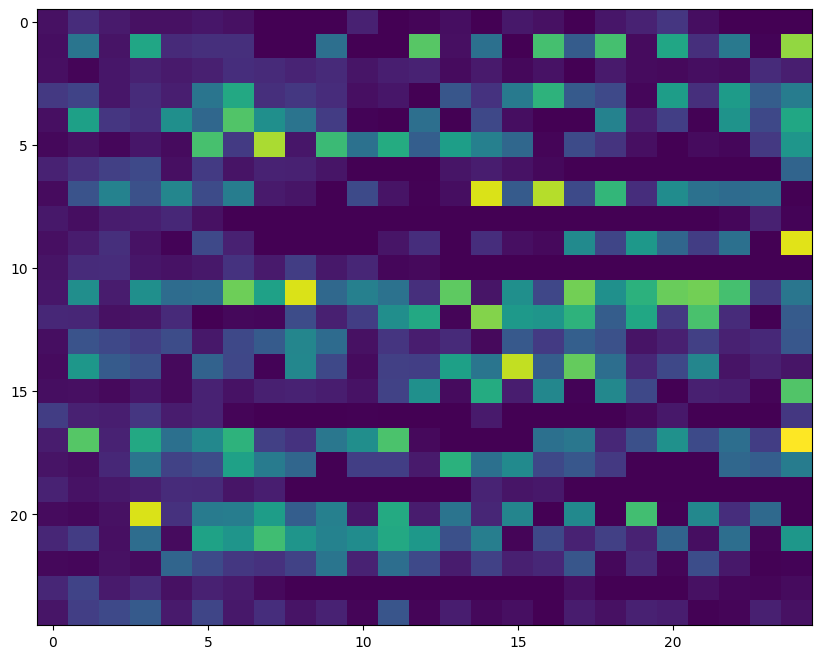

In [471]:
# plot a heatmap of the first simulation
plt.figure(figsize=(10, 8))
plt.imshow(total_results_norm[:,50,:], cmap='viridis', aspect='auto', interpolation='none')

In [460]:
total_results_norm

array([[[63.,  0.,  0., ...,  0.,  0.,  0.],
        [59.,  6.,  0., ...,  0.,  0.,  0.],
        [55., 12.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[63.,  0.,  0., ...,  0.,  0.,  0.],
        [59.,  3.,  0., ...,  0.,  0.,  0.],
        [56.,  6.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 6., 50., 11., ...,  4., 89., 32.],
        [ 6., 50., 11., ...,  4., 89., 32.],
        [ 6., 50., 11., ...,  4., 89., 32.]],

       [[63.,  0.,  0., ...,  0.,  0.,  0.],
        [59.,  5.,  0., ...,  0.,  0.,  0.],
        [55., 10.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       ...,

       [[63.,  0.,  0., ...,  0.,  0.,  0.],
        [60.,  5.,  0., ...,  0.,  4.,  0.],
        [57., 10.,  0., ...,  0.,  8.,  0.

In [472]:
import os


def generate_frames_and_video(results, folder='frames', output_file='output.mov', length = 2000):
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    for i in range(results.shape[1]):
        plt.figure(figsize=(10, 8))
        plt.imshow(results[:,i,:], cmap='gray', aspect='equal', interpolation='none')
        plt.axis('off')
        frame_filename = f'{folder}/frame_{i:04d}.png'
        plt.savefig(frame_filename, bbox_inches='tight', pad_inches=0)
        plt.close()
    
    # Create a video from frames
    images = [imageio.imread(f'{folder}/frame_{i:04d}.png') for i in range(2000)]
    imageio.mimsave(output_file, images, fps=20, format='FFMPEG', codec='libx264')

generate_frames_and_video(total_results_norm, folder='frames', output_file='output.mov')

/var/folders/hz/4pywr0zn1y34rhzrg6_ntgs80000gq/T/ipykernel_97850/252780000.py:17: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(f'{folder}/frame_{i:04d}.png') for i in range(2000)]
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (616, 616) to (624, 624) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [449]:
# Create a video from frames
folder='simulation_frames'
output_file='output2.mov'

images = [imageio.imread(f'{folder}/frame_{i:04d}.png') for i in range(2000)]
imageio.mimsave(output_file, images, fps=20, format='FFMPEG', codec='libx264')



/var/folders/hz/4pywr0zn1y34rhzrg6_ntgs80000gq/T/ipykernel_97850/3277430002.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(f'{folder}/frame_{i:04d}.png') for i in range(2000)]
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 800) to (1008, 800) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [433]:
pip install 'imageio[ffmpeg]'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.5/22.5 MB 9.1 MB/s eta 0:00:0000:01m00:01

[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [408]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def simulate_gene_expression(u0, beta, s, interactions, t_end=50, num_points=1000):
    def grn_model(u, t, beta, s, interactions):
        du_dt = np.zeros_like(u)
        influence = np.dot(interactions.T, u)
        active = (influence > 1.3).astype(int)
        for j in range(len(u)):
            du_dt[j] = beta[j] * active[j] - s[j] * u[j]
        return du_dt
    
    t = np.linspace(0, t_end, num_points)
    result = odeint(grn_model, u0, t, args=(beta, s, interactions))
    return result

def batch_simulations(n_runs, n_genes, num_points):
    voxel = np.zeros((n_runs, n_genes, num_points))
    for i in range(n_runs):
        interactions, u0, beta, s = interaction_block(n_genes)
        voxel[i, :, :] = simulate_gene_expression(u0, beta, s, interactions, t_end=100, num_points=num_points)
    return voxel

# Create the voxel of simulations
n_runs = 25
n_genes = 25
num_points = 2000
voxel = batch_simulations(n_runs, n_genes, num_points)

# Function to animate the gene expression dynamics
def animate(i):
    ax.clear()
    ax.imshow(voxel[:, :, i], cmap='gray', aspect='auto')
    ax.set_title(f"Time step: {i+1}")
    plt.xlabel('Gene Index')
    plt.ylabel('Simulation Index')

fig, ax = plt.subplots(figsize=(10, 8))
ani = FuncAnimation(fig, animate, frames=num_points, repeat=False)
plt.show()

ValueError: could not broadcast input array from shape (2000,25) into shape (25,2000)

/var/folders/hz/4pywr0zn1y34rhzrg6_ntgs80000gq/T/ipykernel_97850/2823095561.py:16: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  result = odeint(grn_model, u0, t, args=(beta, s, interactions))


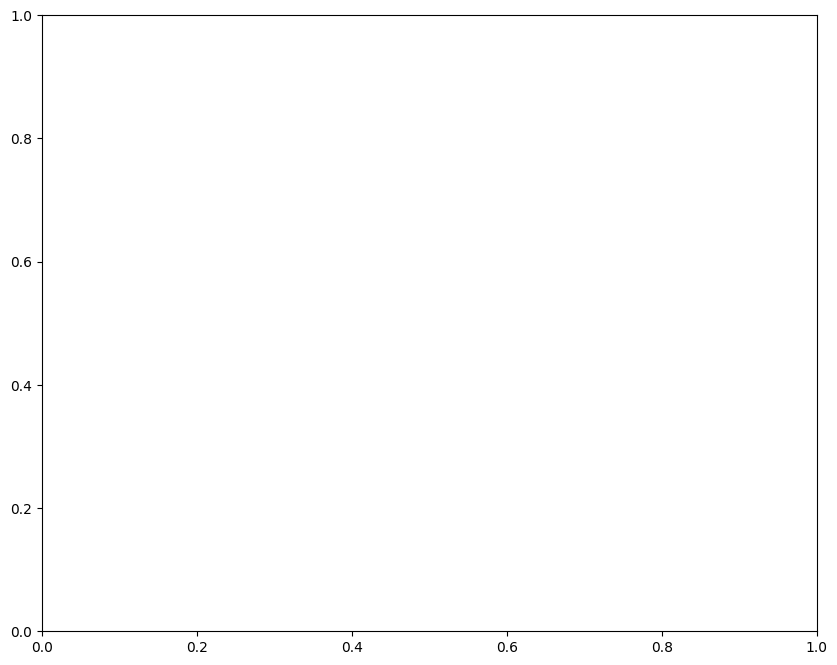

RuntimeError: Requested MovieWriter (ffmpeg) not available

In [413]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def simulate_gene_expression(u0, beta, s, interactions, t_end=50, num_points=1000):
    def grn_model(u, t, beta, s, interactions):
        du_dt = np.zeros_like(u)
        influence = np.dot(interactions.T, u)
        active = (influence > 1.3).astype(int)
        for j in range(len(u)):
            du_dt[j] = beta[j] * active[j] - s[j] * u[j]
        return du_dt
    
    t = np.linspace(0, t_end, num_points)
    result = odeint(grn_model, u0, t, args=(beta, s, interactions))
    return result

def batch_simulations(n_runs, n_genes, num_points):
    voxel = np.zeros((n_runs, n_genes, num_points))
    for i in range(n_runs):
        interactions, u0, beta, s = interaction_block(n_genes)
        result = simulate_gene_expression(u0, beta, s, interactions, t_end=100, num_points=num_points)
        voxel[i, :, :] = result.T  # Transpose the result to fit the voxel dimensions correctly
    return voxel

# Create the voxel of simulations
n_runs = 25
n_genes = 25
num_points = 200
voxel = batch_simulations(n_runs, n_genes, num_points)


def animate(i):
    ax.clear()
    ax.imshow(voxel[:, :, i], cmap='gray', aspect='auto')
    ax.set_title(f"Time step: {i+1}")
    plt.xlabel('Gene Index')
    plt.ylabel('Simulation Index')

# Create and display the animation
fig, ax = plt.subplots(figsize=(10, 8))
ani = FuncAnimation(fig, animate, frames=num_points, repeat=False)
plt.show()

from IPython.display import HTML

# Convert to HTML5 Video
HTML(ani.to_html5_video())


In [410]:
voxel

array([[[ 2.00000000e+00,  1.95256530e+00,  1.90625564e+00, ...,
         -2.55512125e-11, -2.55336741e-11, -2.55161357e-11],
        [ 0.00000000e+00,  1.19538902e-01,  2.36819676e-01, ...,
         -9.95269800e-13, -9.94583408e-13, -9.93897016e-13],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -3.74908420e-13, -3.74649409e-13, -3.74390398e-13],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -5.10373054e-11, -5.10023869e-11, -5.09674684e-11],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -6.45148431e-13, -6.44704061e-13, -6.44259690e-13],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[ 2.00000000e+00,  1.95459947e+00,  1.91022955e+00, ...,
         -7.80014626e-13, -7.79556579e-13, -7.79098531e-13],
        [ 0.00000000e+00,  5.06038561e-02,  1.00142863e-01, ...,
         -3.74649553e-12, -3.74429995e

Text(0.5, 1.0, 'Interaction Matrix with Duplicated Row and Column')

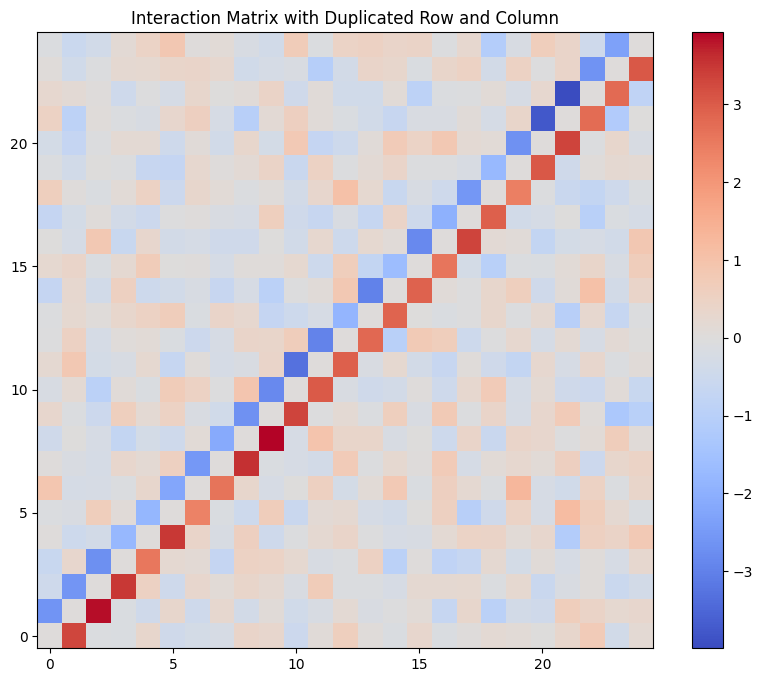

In [341]:
# plot interactions matrix
plt.figure(figsize=(10, 8))
plt.imshow(interactions, cmap='coolwarm', origin='lower')
plt.colorbar()
plt.title('Interaction Matrix with Duplicated Row and Column')

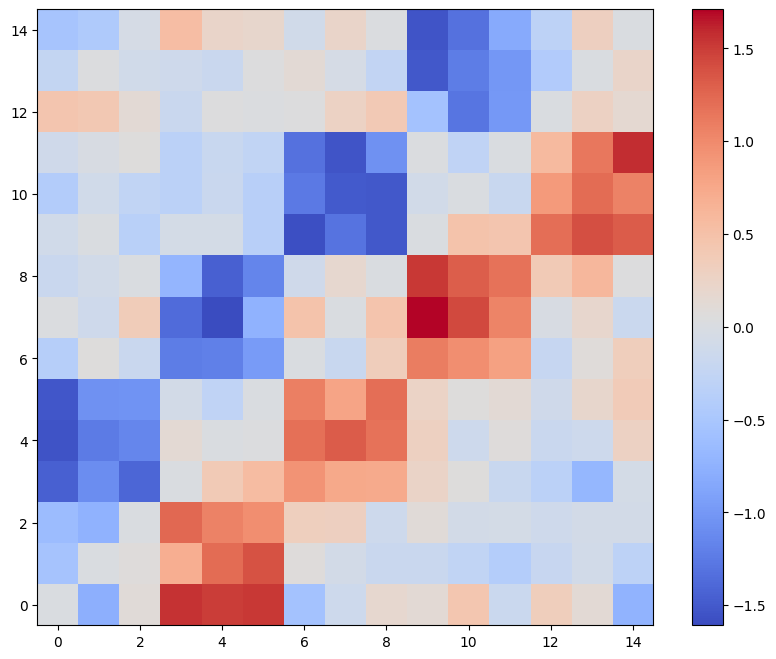

In [277]:
import numpy as np
from scipy.ndimage import gaussian_filter

def interaction_block_row_col_duplicate_with_smoothing(n, k, sigma=1.0):
    """
    Generates an interaction matrix where each gene's interactions are duplicated k times 
    by row and column, adds Gaussian noise, and applies Gaussian smoothing.
    
    Parameters:
    n (int): Number of original genes in the block.
    k (int): Number of times to duplicate each gene's interaction.
    sigma (float): Standard deviation for Gaussian smoothing.
    
    Returns:
    tuple: Tuple containing:
        - interactions (numpy array): The smoothed interaction matrix for the block with duplicated genes.
        - u0 (numpy array): Initial concentrations for all genes in the block.
        - beta (numpy array): Transcription rates for all genes.
        - s (numpy array): Splicing rates for all genes.
    """
    # Create the original interaction matrix with random noise pre-duplication
    original_interactions = np.zeros((n, n))
    for i in range(n-1):
        original_interactions[i, i+1] = 1.4  # +1 above the diagonal
        original_interactions[i+1, i] = -1.4  # -1 below the diagonal

    # Duplicate each row and column k times
    interactions = np.repeat(np.repeat(original_interactions, k, axis=0), k, axis=1)

    # Add Gaussian noise after duplication
    interactions += 0.4 * np.random.randn(n * k, n * k)

    # Apply Gaussian smoothing
    interactions = gaussian_filter(interactions, sigma=sigma)

    # Ensure diagonal elements are zero after smoothing
    np.fill_diagonal(interactions, 0)

    # Parameters for original genes, then duplicated
    original_u0 = np.zeros(n)
    original_u0[np.random.randint(0, n)] = 2  # Randomly activate one gene in original set
    original_beta = 2.2 * np.ones(n)
    original_s = 0.5 * np.ones(n)

    # Duplicate parameters k times for each gene
    u0 = np.repeat(original_u0, k)
    beta = np.repeat(original_beta, k)
    s = np.repeat(original_s, k)

    return interactions, u0, beta, s

# Example usage
n = 5   # Original number of genes
k = 3   # Number of duplicates per gene
interactions, u0, beta, s = interaction_block_row_col_duplicate_with_smoothing(n, k, sigma=0.5)



# plot interactions matrix
plt.figure(figsize=(10, 8))
plt.imshow(interactions, cmap='coolwarm', origin='lower')
plt.colorbar()

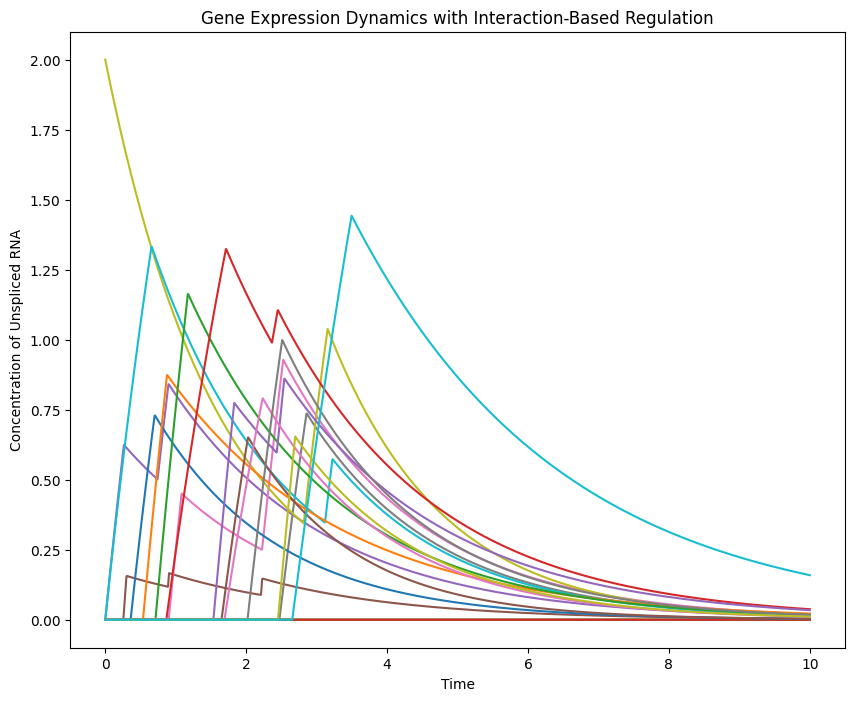

In [303]:
simulate_and_plot_gene_expression(u0, beta, s, interactions, t_end=10, num_points=2000)

Text(0.5, 1.0, 'Interaction Matrix with Duplicated Row and Column')

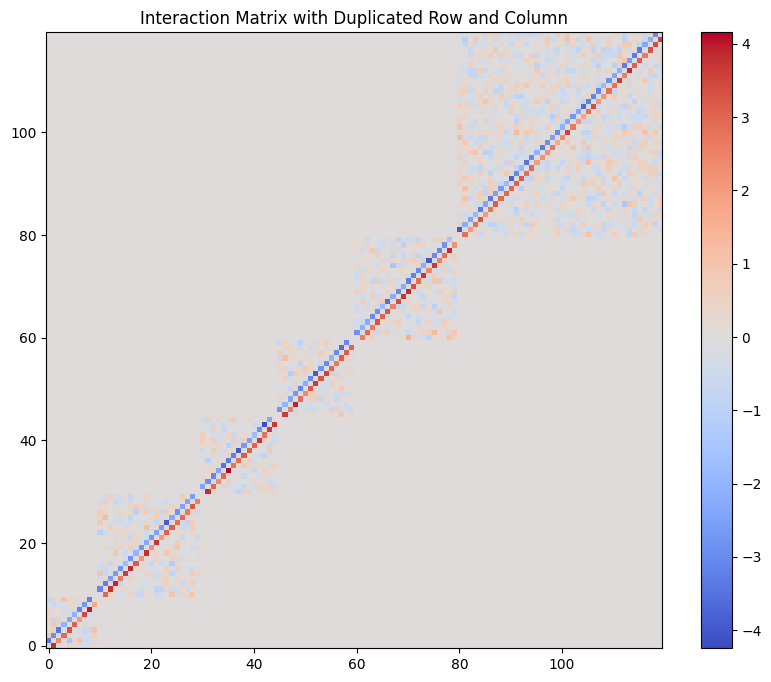

In [304]:
import numpy as np

def generate_interaction_blocks(block_sizes):
    """
    Generates a master interaction matrix consisting of blocks of different sizes along the diagonal,
    each block being a separate sub-network interaction matrix.
    
    Parameters:
    block_sizes (tuple of int): Sizes of each block (sub-network), defining the number of genes per sub-network.
    
    Returns:
    tuple: Tuple containing:
        - master_interaction (numpy array): The master interaction matrix for the whole network.
        - master_u0 (numpy array): Initial concentrations for all genes in the network.
        - master_beta (numpy array): Transcription rates for all genes.
        - master_s (numpy array): Splicing rates for all genes.
    """
    total_size = sum(block_sizes)
    master_interaction = np.zeros((total_size, total_size))
    master_u0 = np.array([])
    master_beta = np.array([])
    master_s = np.array([])

    current_index = 0
    for size in block_sizes:
        interactions, u0, beta, s = interaction_block(size)
        # Place the block in the master interaction matrix
        master_interaction[current_index:current_index + size, current_index:current_index + size] = interactions
        
        # Concatenate the parameters
        master_u0 = np.concatenate((master_u0, u0))
        master_beta = np.concatenate((master_beta, beta))
        master_s = np.concatenate((master_s, s))
        
        current_index += size
    
    return master_interaction, master_u0, master_beta, master_s

# Example usage
block_sizes = (10, 20, 15, 15, 20, 40)  # Example with different block sizes
master_interaction, master_u0, master_beta, master_s = generate_interaction_blocks(block_sizes)

# plot interactions matrix
plt.figure(figsize=(10, 8))
plt.imshow(master_interaction, cmap='coolwarm', origin='lower')
plt.colorbar()
plt.title('Interaction Matrix with Duplicated Row and Column')

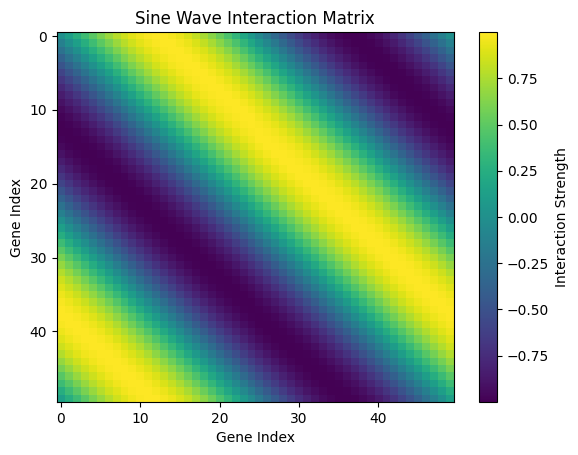

In [218]:
import numpy as np
import matplotlib.pyplot as plt

def generate_sine_interaction_matrix(n):
    """
    Generates an interaction matrix where each row is a sine wave. The period of the sine
    function is equal to the number of genes, and the phase shift increases uniformly across rows.
    
    Parameters:
    n (int): Number of genes (and thus the period of the sine wave).
    
    Returns:
    numpy array: The sine wave-based interaction matrix.
    """
    # Initialize the interaction matrix
    interaction_matrix = np.zeros((n, n))
    
    # Define the x values, which are the same for all sine functions
    x = np.linspace(0, 2 * np.pi, n)
    
    # Generate each row with a different phase shift
    for i in range(n):
        # Calculate phase shift to cover all phases uniformly across the rows
        phase_shift = -(2 * np.pi / n) * i
        interaction_matrix[i, :] = np.sin(x + phase_shift)
    
    return interaction_matrix

# Example usage
n = 50  # Number of genes
interaction_matrix = generate_sine_interaction_matrix(n)

# Optionally, visualize the interaction matrix
plt.imshow(interaction_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Interaction Strength')
plt.title('Sine Wave Interaction Matrix')
plt.xlabel('Gene Index')
plt.ylabel('Gene Index')
plt.show()



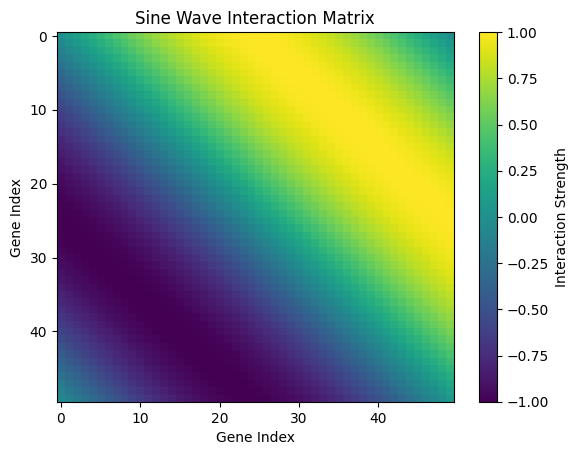

In [217]:
import numpy as np
import matplotlib.pyplot as plt

def generate_half_sine_interaction_matrix(n):
    """
    Generates an interaction matrix where each row is a sine wave. The period of the sine
    function is equal to the number of genes, and the phase shift increases uniformly across rows.
    
    Parameters:
    n (int): Number of genes (and thus the period of the sine wave).
    
    Returns:
    numpy array: The sine wave-based interaction matrix.
    """
    # Initialize the interaction matrix
    interaction_matrix = np.zeros((n, n))
    
    # Define the x values, which are the same for all sine functions
    x = np.linspace(0, np.pi, n)
    
    # Generate each row with a different phase shift
    for i in range(n):
        # Calculate phase shift to cover all phases uniformly across the rows
        phase_shift = -(np.pi / n) * i
        interaction_matrix[i, :] = np.sin(x + phase_shift)
    
    return interaction_matrix

# Example usage
n = 50  # Number of genes
interaction_matrix = generate_half_sine_interaction_matrix(n)

# Optionally, visualize the interaction matrix
plt.imshow(interaction_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Interaction Strength')
plt.title('Sine Wave Interaction Matrix')
plt.xlabel('Gene Index')
plt.ylabel('Gene Index')
plt.show()

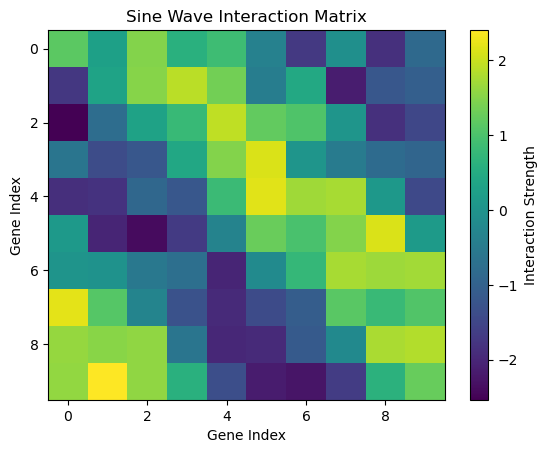

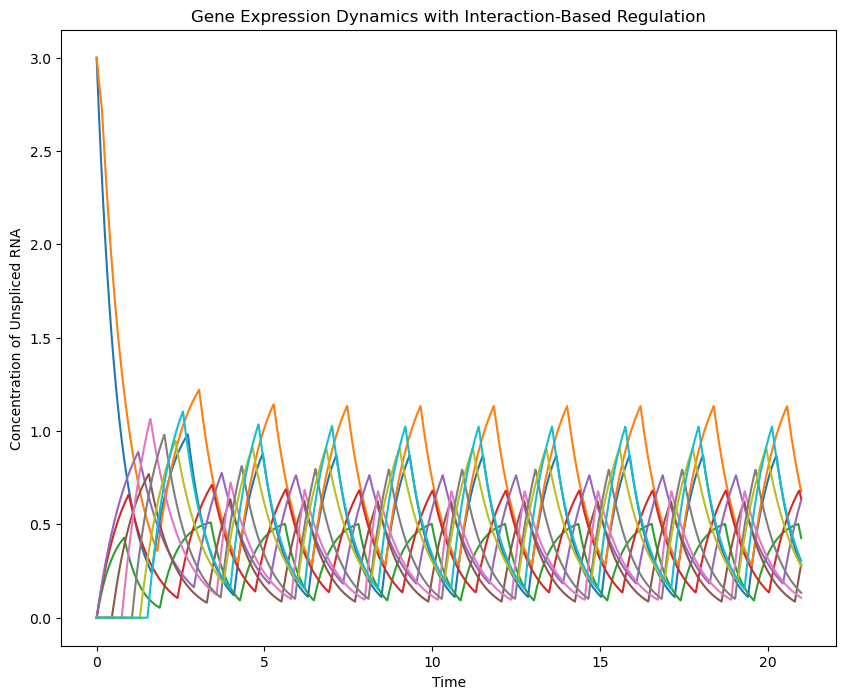

array([[3.        , 3.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [2.95197657, 2.98016665, 0.01096919, ..., 0.        , 0.        ,
        0.        ],
       [2.90472197, 2.96058836, 0.0217136 , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.28886649, 0.69538917, 0.44477007, ..., 0.13742674, 0.28417536,
        0.31527188],
       [0.28424238, 0.68644741, 0.43565706, ..., 0.13554517, 0.28079472,
        0.31069724],
       [0.27969228, 0.67762064, 0.42673077, ..., 0.13368936, 0.2774543 ,
        0.30618898]])

In [221]:
import numpy as np
import matplotlib.pyplot as plt

def generate_sine_interaction_matrix_and_parameters(n):
    """
    Generates an interaction matrix where each row is a sine wave with a period equal to the number of genes,
    and the phase shift increases uniformly across rows. Also generates initial concentrations, transcription rates,
    and splicing rates for each gene.
    
    Parameters:
    n (int): Number of genes (and thus the period of the sine wave).
    
    Returns:
    tuple: Tuple containing:
        - interaction_matrix (numpy array): The sine wave-based interaction matrix.
        - u0 (numpy array): Initial concentrations of unspliced RNA for each gene.
        - beta (numpy array): Transcription rates for each gene.
        - s (numpy array): Splicing rates for each gene.
    """
    # Interaction matrix initialization
    interaction_matrix = np.zeros((n, n))
    x = np.linspace(0, 2 * np.pi, n)  # Period spanning one complete sine wave
    
    # Generate interaction matrix with varying phase shifts
    for i in range(n):
        phase_shift = -(2 * np.pi / n) * i  # Uniform phase shifts across rows
        interaction_matrix[i, :] = np.sin(x + phase_shift)

    interaction_matrix = 2 * interaction_matrix  # Scale interaction matrix

    # add some random noise to the matrix
    interaction_matrix += 0.5 * np.random.randn(n, n)
    
    # Initialize parameters: u0, beta, s
    u0 = np.zeros(n)  # Random initial concentrations between 0 and 10
    u0[:2] = 3
    beta = np.random.rand(n) * 1 + 1  # Random transcription rates between 1 and 3
    s = np.random.rand(n) * 1 + 1  # Random splicing rates between 0.1 and 0.6



    return interaction_matrix, u0, beta, s

# Example usage
n = 10  # Number of genes
interactions, u0, beta, s = generate_sine_interaction_matrix_and_parameters(n)

# Optionally, visualize the interaction matrix
plt.imshow(interactions, cmap='viridis', aspect='auto')
plt.colorbar(label='Interaction Strength')
plt.title('Sine Wave Interaction Matrix')
plt.xlabel('Gene Index')
plt.ylabel('Gene Index')
plt.show()


simulate_and_plot_gene_expression(u0, beta, s, interactions, t_end=21, num_points=2000, thresh = 0.87)

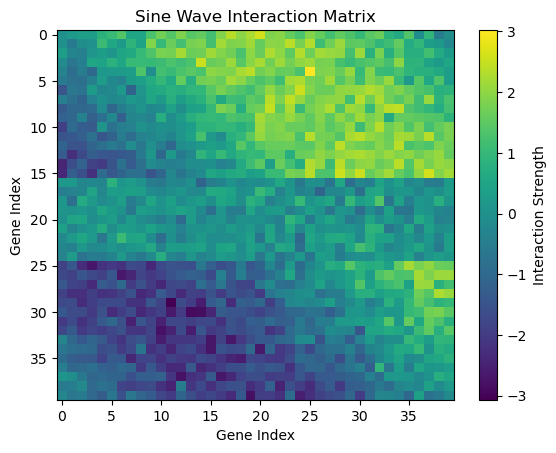

In [215]:
import numpy as np
import matplotlib.pyplot as plt

def generate_halfsine_interaction_matrix_and_parameters(n):
    """
    Generates an interaction matrix where each row is a sine wave with a period equal to the number of genes,
    and the phase shift increases uniformly across rows. Also generates initial concentrations, transcription rates,
    and splicing rates for each gene.
    
    Parameters:
    n (int): Number of genes (and thus the period of the sine wave).
    
    Returns:
    tuple: Tuple containing:
        - interaction_matrix (numpy array): The sine wave-based interaction matrix.
        - u0 (numpy array): Initial concentrations of unspliced RNA for each gene.
        - beta (numpy array): Transcription rates for each gene.
        - s (numpy array): Splicing rates for each gene.
    """
    # Interaction matrix initialization
    interaction_matrix = np.zeros((n, n))
    x = np.linspace(0, np.pi, n)  # Period spanning one complete sine wave
    
    # Generate interaction matrix with varying phase shifts
    for i in range(n):
        phase_shift = -(np.pi / n) * i  # Uniform phase shifts across rows

        k = np.pi/100
        for j in range(n):
            if -k < x[j]+ phase_shift < k: 
                interaction_matrix[i, :] = np.sin(x + phase_shift)

    interaction_matrix = 2 * interaction_matrix  # Scale interaction matrix

    # add some random noise to the matrix
    interaction_matrix += 0.4 * np.random.randn(n, n)
    
    # Initialize parameters: u0, beta, s
    u0 = np.zeros(n)  # Random initial concentrations between 0 and 10
    u0[:2] = 1
    beta = np.random.rand(n) * 1 + 1  # Random transcription rates between 1 and 3
    s = np.random.rand(n) * 1 + 1  # Random splicing rates between 0.1 and 0.6



    return interaction_matrix, u0, beta, s

# Example usage
n = 40  # Number of genes
interactions, u0, beta, s = generate_halfsine_interaction_matrix_and_parameters(n)

# Optionally, visualize the interaction matrix
plt.imshow(interactions, cmap='viridis', aspect='auto')
plt.colorbar(label='Interaction Strength')
plt.title('Sine Wave Interaction Matrix')
plt.xlabel('Gene Index')
plt.ylabel('Gene Index')
plt.show()




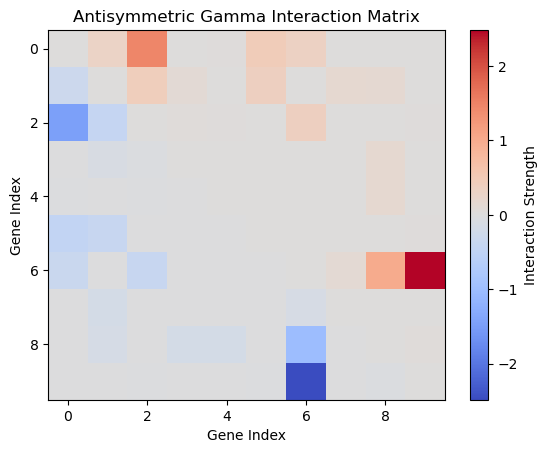

In [219]:
from scipy.stats import gamma 

def generate_gamma_interaction_matrix(n, gamma_shape, gamma_scale):
    """
    Generates an interaction matrix where each row follows a gamma distribution starting 
    from the diagonal with zeros before the diagonal, then computes the antisymmetric matrix.
    
    Parameters:
    n (int): Number of genes (size of the matrix).
    gamma_shape (float): Shape parameter for the gamma distribution.
    gamma_scale (float): Scale parameter for the gamma distribution.
    
    Returns:
    numpy array: The antisymmetric interaction matrix.
    """
    # Initialize the interaction matrix with zeros
    interaction_matrix = np.zeros((n, n))
    
    # Fill each row with values from the gamma distribution starting from the diagonal
    for i in range(n):
        # Generate gamma-distributed values for the row starting from the diagonal
        interaction_matrix[i, i:] = gamma.rvs(a=gamma_shape, scale=gamma_scale, size=n-i)
    
    # Antisymmetrize the matrix
    antisymmetric_matrix = interaction_matrix - interaction_matrix.T
    
    return antisymmetric_matrix

# Example usage
n = 10  # Number of genes (size of the matrix)
gamma_shape = 0.2  # Shape parameter for the gamma distribution
gamma_scale = 1.0  # Scale parameter for the gamma distribution

antisymmetric_interaction_matrix = generate_gamma_interaction_matrix(n, gamma_shape, gamma_scale)

# Optionally, visualize the antisymmetric interaction matrix
plt.imshow(antisymmetric_interaction_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Interaction Strength')
plt.title('Antisymmetric Gamma Interaction Matrix')
plt.xlabel('Gene Index')
plt.ylabel('Gene Index')
plt.show()

In [220]:
simulate_and_plot_gene_expression(u0, beta, s, interactions, t_end=5, num_points=2000, thresh = 32

SyntaxError: incomplete input (3045820315.py, line 1)